In [16]:
import os
import pandas as pd

# Vérifier où vous êtes
print("Dossier courant:", os.getcwd())

# Vérifier si le fichier existe
fichier = "BD_2016_2020_TableauDynamique (1).xlsx"
if os.path.exists(fichier):
    print(f"Fichier trouvé: {fichier}")
    print(f"Taille: {os.path.getsize(fichier)} octets")
else:
    print(f"Fichier NON trouvé: {fichier}")
    print("\nPlacez le fichier dans:", os.getcwd())

Dossier courant: /mnt/home/4/0/406115
Fichier trouvé: BD_2016_2020_TableauDynamique (1).xlsx
Taille: 396591710 octets


In [17]:
# Essayer de lire les noms des feuilles
try:
    # Ouvrir le fichier Excel
    xl = pd.ExcelFile(fichier, engine='openpyxl')
    
    # Afficher toutes les feuilles
    feuilles = xl.sheet_names
    print(f"{len(feuilles)} feuille(s) trouvée(s):\n")
    
    for i, nom in enumerate(feuilles, 1):
        print(f"{i}. {nom}")
        
except Exception as e:
    print(f" Erreur: {e}")
    print("\nSolution possible:")
    print("1. Installez openpyxl: pip install openpyxl")
    print("2. Ou essayez avec un autre moteur")

3 feuille(s) trouvée(s):

1. Feuil4
2. Extraction juin 2016 juin 2020
3. Feuil1


In [18]:
fichier = "BD_2016_2020_TableauDynamique (1).xlsx"

try:
    # Lire toutes les feuilles
    toutes_les_feuilles = pd.read_excel(fichier, sheet_name=None, engine='openpyxl')
    0
    print(f" {len(toutes_les_feuilles)} feuille(s) chargée(s) avec succès!\n")
    
    # Afficher les infos de chaque feuille
    for nom_feuille, df in toutes_les_feuilles.items():
        print(f" FEUILLE: {nom_feuille}")
        print(f" Lignes: {df.shape[0]}")
        print(f" Colonnes: {df.shape[1]}")
        print(f" Mémoire: {df.memory_usage().sum() / 1024:.1f} Ko")
        print("-" * 50)
        
except Exception as e:
    print(f"Erreur: {e}")

 3 feuille(s) chargée(s) avec succès!

 FEUILLE: Feuil4
 Lignes: 0
 Colonnes: 0
 Mémoire: 0.1 Ko
--------------------------------------------------
 FEUILLE: Extraction juin 2016 juin 2020
 Lignes: 336253
 Colonnes: 41
 Mémoire: 107706.2 Ko
--------------------------------------------------
 FEUILLE: Feuil1
 Lignes: 69985
 Colonnes: 41
 Mémoire: 22417.2 Ko
--------------------------------------------------


In [19]:
print("EXPLORATION DÉTAILLÉE DES FEUILLES")
print("="*60)

for nom_feuille, df in toutes_les_feuilles.items():
    print(f"\n FEUILLE: '{nom_feuille}'")
    print(f" Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f" Mémoire utilisée: {df.memory_usage().sum() / (1024*1024):.2f} Mo")
    
    # Afficher les premières lignes
    print(f"\n PREMIÈRES LIGNES (5 premières):")
    print(df.head())
    
    # Afficher les colonnes
    print(f"\n  COLONNES ({len(df.columns)} total):")
    for i, col in enumerate(df.columns, 1):
        print(f"   {i:2d}. {col}")


EXPLORATION DÉTAILLÉE DES FEUILLES

 FEUILLE: 'Feuil4'
 Dimensions: 0 lignes × 0 colonnes
 Mémoire utilisée: 0.00 Mo

 PREMIÈRES LIGNES (5 premières):
Empty DataFrame
Columns: []
Index: []

  COLONNES (0 total):

 FEUILLE: 'Extraction juin 2016 juin 2020'
 Dimensions: 336253 lignes × 41 colonnes
 Mémoire utilisée: 105.18 Mo

 PREMIÈRES LIGNES (5 premières):
   Num d'ordre       Date     Heure  \
0            1 2016-06-01  00:16:00   
1            2 2016-06-01  00:18:00   
2            3 2016-06-01  00:36:00   
3            4 2016-06-01  00:43:00   
4            5 2016-06-01  01:16:00   

   Informations du passage->date et heure d'arrivée  \
0                               2016-06-01 00:16:00   
1                               2016-06-01 00:18:00   
2                               2016-06-01 00:36:00   
3                               2016-06-01 00:43:00   
4                               2016-06-01 01:16:00   

   Informations du passage->moyen d'arrivée  \
0                          

In [20]:
# Base brute (jamais modifiée)
df_raw = toutes_les_feuilles["Extraction juin 2016 juin 2020"].copy()

# DataFrame de travail
df = df_raw.copy()
print(df.shape)
df.head()

(336253, 41)


,Num d'ordre,Date,Heure,Informations du passage->date et heure d'arrivée,Informations du passage->moyen d'arrivée,IAO->motif d'entrée,IAO->motif de venue,Patient->age en année,Antécédent->antécédents médicaux,Antécédent->antécédents chirurgicaux,...,Informations du passage->CAC du séjour,Informations du passage->date et heure de sortie,Informations du passage->date début prise en charge médicale,Informations du passage->dossier dans l'hôpital,Orientation->type d'orientation,Orientation->destination,Orientation->tansfert vers le service,Orientation->transfert vers l'hôpital,Patient->code postal de la ville,Patient->nom de la ville
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,...,3093.0,42522.176389,42522.043750,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59139,WATTIGNIES
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,...,3102.0,42522.461806,42522.093056,NaN,TRANSFERT EXTERNE,Transfert CLINIQUE DUBOIS (LILLE) Motif: Conve...,NaN,CLINIQUE DUBOIS,59310,ORCHIES
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,...,3102.0,42522.127778,NaN,NaN,TRANSFERT INTERNE,Admis(e) en NEUROLOGIE B 5 EST (3281/CAC),NEUROLOGIE B 5 EST,NaN,59480,LA BASSEE
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,...,3093.0,42522.201389,42522.081250,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59136,WAVRIN
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,...,3102.0,42522.663194,42522.107639,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59130,LAMBERSART


In [ ]:
# Sélection de la feuille principale pour l'EDA
#df = toutes_les_feuilles["Extraction juin 2016 juin 2020"]

# Vérification rapide
#print(df.shape)
#df.head()

« Parmi les feuilles disponibles dans la base fournie, la feuille “Extraction juin 2016 juin 2020” a été retenue pour l’analyse, car elle regroupe l’ensemble des passages aux Services des Urgences Adultes sur une période de quatre années complètes, tout en conservant la même structure de variables que les autres feuilles. Cette richesse temporelle et volumique permet une analyse statistique plus robuste et une modélisation plus représentative du fonctionnement réel du service. »

In [21]:
# Affichage des types de variables
df.dtypes

Num d'ordre                                                                              int64
Date                                                                            datetime64[ns]
Heure                                                                                   object
 Informations du passage->date et heure d'arrivée                               datetime64[ns]
 Informations du passage->moyen d'arrivée                                               object
 IAO->motif d'entrée                                                                    object
 IAO->motif de venue                                                                    object
 Patient->age en année                                                                   int64
 Antécédent->antécédents médicaux                                                       object
 Antécédent->antécédents chirurgicaux                                                   object
 Constante->Surveillances->PAS/PAD adultes (premiè

In [ ]:
# Résumé des types de données
df.dtypes.value_counts()

In [22]:
# Nombre et pourcentage de valeurs manquantes par colonne
missing = pd.DataFrame({
    "nb_manquants": df.isna().sum(),
    "pourcentage": df.isna().mean() * 100
}).sort_values("pourcentage", ascending=False)

missing

,nb_manquants,pourcentage
Informations du passage->dossier dans l'hôpital,336247,99.998216
Orientation->transfert vers l'hôpital,329461,97.980092
Constante->Surveillances->Fréquence Respiratoire (première valeur),325468,96.792594
IAO->observation,307694,91.506693
Orientation->tansfert vers le service,269101,80.029323
Antécédent->antécédents chirurgicaux,265119,78.845096
Antécédent->antécédents médicaux,233630,69.480421
Examens complémentaires->date et heure de premier prélèvement de biologie,171772,51.084154
Examens complémentaires->date et heure de première prescription de biologie,168805,50.201783
Anamnèse->texte,158225,47.055342


👉 Table nb_manquants / pourcentage

Très important :
Certaines colonnes ont > 90 % de NaN/
dossier hôpital/
observation IAO/
constantes vitales
    
D’autres sont quasi complètes (âge, date arrivée, orientation)

👉 Ce n’est PAS un problème
👉 C’est structurel aux urgences (tout n’est pas renseigné)

In [23]:
# Colonnes avec plus de 50% de valeurs manquantes
missing[missing["pourcentage"] > 50]

,nb_manquants,pourcentage
Informations du passage->dossier dans l'hôpital,336247,99.998216
Orientation->transfert vers l'hôpital,329461,97.980092
Constante->Surveillances->Fréquence Respiratoire (première valeur),325468,96.792594
IAO->observation,307694,91.506693
Orientation->tansfert vers le service,269101,80.029323
Antécédent->antécédents chirurgicaux,265119,78.845096
Antécédent->antécédents médicaux,233630,69.480421
Examens complémentaires->date et heure de premier prélèvement de biologie,171772,51.084154
Examens complémentaires->date et heure de première prescription de biologie,168805,50.201783


In [24]:
# Statistiques descriptives pour les variables numériques
df.describe()

,Num d'ordre,Date,Informations du passage->date et heure d'arrivée,Patient->age en année,Localisation->date d'entrée en box,Examens complémentaires->date et heure de première prescription de biologie,Examens complémentaires->date et heure de premier prélèvement de biologie,Informations du passage->CAC du séjour,Informations du passage->date et heure de sortie,Informations du passage->date début prise en charge médicale,Informations du passage->dossier dans l'hôpital
count,336253.00000,336253,336253,336253.000000,186938.000000,167448.000000,164481.000000,336243.000000,336253.000000,298023.000000,6.000000
mean,168127.00000,2018-05-19 03:15:29.225315328,2018-05-19 17:24:24.712819968,44.633229,43233.711650,43244.628868,43244.008531,3092.852648,43240.064384,43233.523440,2.000000
min,1.00000,2016-06-01 00:00:00,2016-06-01 00:16:00,15.000000,42522.028472,42522.062500,42522.065278,3082.000000,42522.127778,42522.043750,1.000000
25%,84064.00000,2017-05-30 00:00:00,2017-05-30 20:06:00,26.000000,42880.430903,42886.575521,42885.815972,3088.000000,42886.218750,42876.354514,2.000000
50%,168127.00000,2018-05-17 00:00:00,2018-05-17 23:48:00,40.000000,43230.473958,43244.678819,43244.036806,3093.000000,43238.574306,43228.461111,2.000000
75%,252190.00000,2019-05-06 00:00:00,2019-05-06 21:43:00,60.000000,43584.465104,43598.727083,43598.527083,3093.000000,43592.524306,43589.785764,2.000000
max,336253.00000,2020-06-01 00:00:00,2020-06-01 23:54:00,218.000000,43984.184028,65797.250000,43984.223611,3103.000000,43986.737500,43984.425694,3.000000
std,97068.02437,NaN,NaN,21.182535,409.814611,417.384125,413.895113,5.752269,411.032109,413.033453,0.632456


Les colonnes commencent avec des espaces parasites !!!! voir en bas 

In [25]:
# Afficher les colonnes avec leur représentation exacte
for col in df.columns:
    print(repr(col))

"Num d'ordre"
'Date'
'Heure'
" Informations du passage->date et heure d'arrivée"
" Informations du passage->moyen d'arrivée"
" IAO->motif d'entrée"
' IAO->motif de venue'
' Patient->age en année'
' Antécédent->antécédents médicaux'
' Antécédent->antécédents chirurgicaux'
' Constante->Surveillances->PAS/PAD adultes (première valeur)'
' Constante->Surveillances->FC adultes (première valeur)'
' Constante->Surveillances->Température adultes (première valeur)'
' Constante->Surveillances->SaO2 adultes (première valeur)'
' Constante->Surveillances->Fréquence Respiratoire (première valeur)'
' Diagnostic->Code CCMU'
' Localisation->Salles'
" Localisation->date d'entrée en box"
' Anamnèse->texte'
' IAO->observation'
' Examens complémentaires->a des examens de biologie'
' Examens complémentaires->a des examens de radiologie'
" Examens complémentaires->a des examens d'échographie"
' Examens complémentaires->a des examens de scanner'
" Examens complémentaires->a des examens d'IRM"
' Examens complém

In [26]:
# Nettoyage des noms de colonnes (espaces au début / fin)
df.columns = df.columns.str.strip()

In [27]:
# Vérification des âges aberrants
df["Patient->age en année"].describe()


count    336253.000000
mean         44.633229
std          21.182535
min          15.000000
25%          26.000000
50%          40.000000
75%          60.000000
max         218.000000
Name: Patient->age en année, dtype: float64

👶 Âge des patients :
min = 15/
max = 218 ❌

1 valeur aberrante détectée
👉 Erreur de saisie évidente

⚠️ Nettoyage ciblé (1 ligne seulement)

In [28]:
# Comptage des âges incohérents
ages_aberrants = df[
    (df["Patient->age en année"] < 0) |
    (df["Patient->age en année"] > 120)
]

ages_aberrants.shape
  

(1, 41)

In [29]:
# Température corporelle
df["Constante->Surveillances->Température adultes (première valeur)"].describe()

count     267414
unique       109
top           36
freq       20174
Name: Constante->Surveillances->Température adultes (première valeur), dtype: int64

In [30]:
# Saturation en oxygène (SaO2)
df["Constante->Surveillances->SaO2 adultes (première valeur)"].describe()

count     225761
unique       576
top           98
freq       42182
Name: Constante->Surveillances->SaO2 adultes (première valeur), dtype: int64

In [40]:
# Saturation en oxygène (SaO2)
df["Constante->Surveillances->SaO2 adultes (première valeur)"].describe()

count     225761
unique       576
top           98
freq       42182
Name: Constante->Surveillances->SaO2 adultes (première valeur), dtype: int64

Constantes vitales :
Température, SaO2, FC, PAS…/
Beaucoup de valeurs manquantes/
Valeurs plausibles majoritaires (36°C, SaO2=98)

⚠️ Conversion en numérique nécessaire
❌ Ne PAS imputer arbitrairement

In [51]:
#####

# arrivée (déjà datetime)
df["arrivee_dt"] = pd.to_datetime(
    df["Informations du passage->date et heure d'arrivée"],
    errors="coerce"
)

# sortie (format Excel)
df["sortie_dt"] = pd.to_datetime(
    df["Informations du passage->date et heure de sortie"],
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

# prise en charge médicale (format Excel)
df["pec_dt"] = pd.to_datetime(
    df["Informations du passage->date début prise en charge médicale"],
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)


In [52]:
df[["arrivee_dt", "sortie_dt", "pec_dt"]].dtypes

arrivee_dt    datetime64[ns]
sortie_dt     datetime64[ns]
pec_dt        datetime64[ns]
dtype: object

In [53]:
incoh_sortie = df[df["sortie_dt"] < df["arrivee_dt"]]
incoh_sortie.shape

(10, 45)

In [54]:
incoh_pec = df[df["pec_dt"] < df["arrivee_dt"]]
incoh_pec.shape

(4, 45)

In [86]:
# Conversion en datetime (colonnes déjà propres)
date_cols = [
    "Informations du passage->date et heure d'arrivée",
    "Informations du passage->date et heure de sortie",
    "Informations du passage->date début prise en charge médicale",
    "Localisation->date d'entrée en box"
]

for col in date_cols:
    df[col + "_dt"] = pd.to_datetime(df[col], errors="coerce")


In [87]:
df[date_cols].dtypes

Informations du passage->date et heure d'arrivée                datetime64[ns]
Informations du passage->date et heure de sortie                       float64
Informations du passage->date début prise en charge médicale           float64
Localisation->date d'entrée en box                                     float64
dtype: object

In [88]:
import pandas as pd

# Colonnes déjà propres (datetime)
df["arrivee_dt"] = df["Informations du passage->date et heure d'arrivée"]

# Colonnes au format Excel (float)
excel_date_cols = {
    "Informations du passage->date et heure de sortie": "sortie_dt",
    "Informations du passage->date début prise en charge médicale": "pec_dt",
    "Localisation->date d'entrée en box": "box_dt"
}

for col, new_col in excel_date_cols.items():
    df[new_col] = pd.to_datetime(
        df[col],
        unit="D",                 # unité Excel (jours)
        origin="1899-12-30",      # origine Excel
        errors="coerce"           # valeurs invalides → NaT
    )

In [89]:
# Sortie avant arrivée
incoh_sortie = df[
    df["Informations du passage->date et heure de sortie_dt"] <
    df["Informations du passage->date et heure d'arrivée_dt"]
]

incoh_sortie.shape

(336252, 51)

In [90]:
# arrivée (déjà datetime)
df["arrivee_dt"] = pd.to_datetime(
    df["Informations du passage->date et heure d'arrivée"],
    errors="coerce"
)

# sortie (Excel)
df["sortie_dt"] = pd.to_datetime(
    df["Informations du passage->date et heure de sortie"],
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

# prise en charge médicale (Excel)
df["pec_dt"] = pd.to_datetime(
    df["Informations du passage->date début prise en charge médicale"],
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

In [91]:
df[["arrivee_dt", "sortie_dt", "pec_dt"]].dtypes

arrivee_dt    datetime64[ns]
sortie_dt     datetime64[ns]
pec_dt        datetime64[ns]
dtype: object

In [92]:
# Prise en charge avant arrivée
incoh_pec = df[
    df["Informations du passage->date début prise en charge médicale_dt"] <
    df["Informations du passage->date et heure d'arrivée_dt"]
]

incoh_pec.shape

(298023, 51)

In [93]:
# Doublons exacts
df.duplicated().sum()

np.int64(0)

In [94]:
# Doublons sur un sous-ensemble logique
df.duplicated(subset=[
    "Num d'ordre",
    "Informations du passage->date et heure d'arrivée",
    "Patient->age en année"
]).sum()

np.int64(0)

Doublons:
Aucun doublon exact/
Aucun doublon logique

✅ Très bon point qualité

<Axes: xlabel='heure_arrivee'>

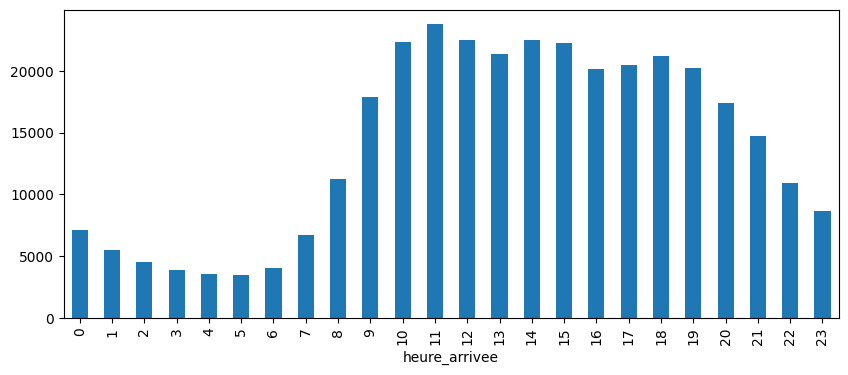

In [95]:
# Extraction de l'heure d'arrivée
df["heure_arrivee"] = df["Informations du passage->date et heure d'arrivée_dt"].dt.hour

df["heure_arrivee"].value_counts().sort_index().plot(kind="bar", figsize=(10,4))

Ce que ça montre:
Faible afflux entre 2h et 6h
Forte hausse dès 8h
Pic entre 10h et 15h
Baisse progressive après 18h

Interprétation intra-urgences : 
Charge maximale en journée 
Problème potentiel de sous-dimensionnement du personnel en fin de matinée / début d’après-midi
Nuit plus calme → logique organisationnelle

✅ Donnée cohérente, exploitable
❌ Rien à nettoyer ici (variable construite)

<Axes: xlabel='date_arrivee'>

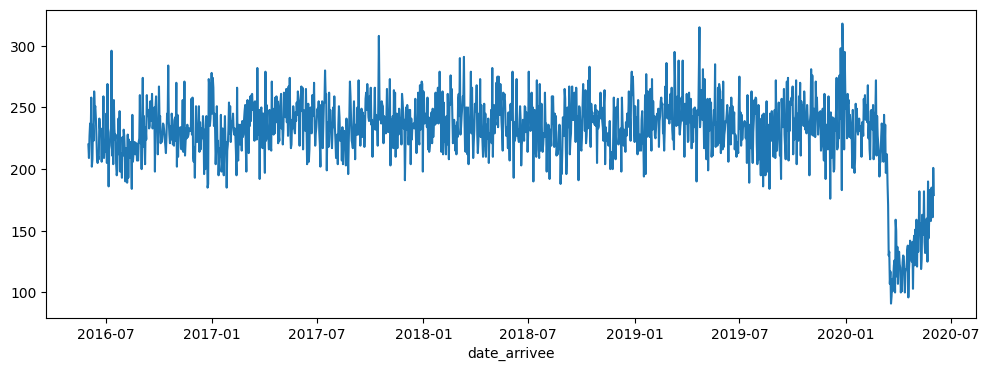

In [96]:
df["date_arrivee"] = df["Informations du passage->date et heure d'arrivée_dt"].dt.date
df["date_arrivee"].value_counts().sort_index().plot(figsize=(12,4))

Ce que ça montre:
Volume stable de 2016 à début 2020
Chute brutale début 2020

Interprétation:
Effet COVID (moins de passages aux urgences)
Donnée réelle, pas une erreur

⚠️ À JUSTIFIER dans le rapport
❌ Ne PAS nettoyer (ce n’est pas un outlier technique)

In [57]:
df["Diagnostic->Code CCMU"].map(type).value_counts()

Diagnostic->Code CCMU
<class 'int'>      286827
<class 'float'>     43131
<class 'str'>        6295
Name: count, dtype: int64

In [58]:
df["Diagnostic->Code CCMU"].value_counts(dropna=False)

Diagnostic->Code CCMU
2      229295
NaN     43131
1       33293
3       19637
P        6068
4        2864
5        1738
D         227
Name: count, dtype: int64

<Axes: xlabel='Diagnostic->Code CCMU'>

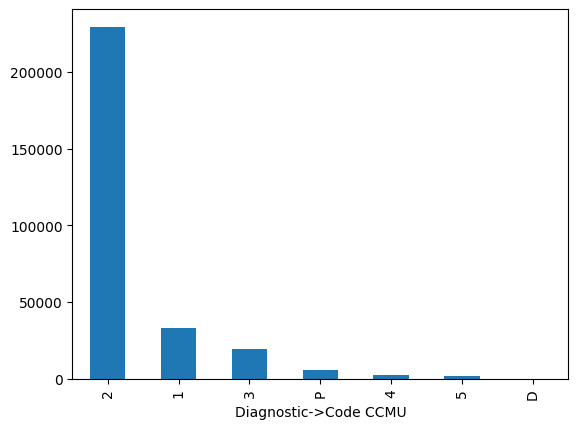

In [59]:
df["Diagnostic->Code CCMU"] \
    .value_counts() \
    .plot(kind="bar")

Ce que ça montre:
Très forte majorité de CCMU = 2--
Valeurs présentes : 1, 2, 3, 4, 5, P, D--
Mélange de types : int, float, str

Interprétation:
Problème de typage, pas de contenu--
NaN = diagnostic non codé (fréquent aux urgences)

⚠️ Nettoyage nécessaire (harmonisation des types)
❌ Ne PAS supprimer les NaN

In [60]:
df_small = toutes_les_feuilles["Feuil1"]

print("Extraction:", df.shape)
print("Feuil1:", df_small.shape)

Extraction: (336253, 45)
Feuil1: (69985, 41)


🧾 Structure du DataFrame
336 253 lignes/
41 à 51 colonnes

Données hétérogènes (texte, dates, constantes, orientation…)/
✅ Taille cohérente pour un SI hospitalier

In [61]:
# Vérification si Feuil1 est un sous-ensemble
df_small.equals(df.iloc[:df_small.shape[0]])

False

Liste EXHAUSTIVE de ce qui est OK

✔️ Volume de données cohérent
✔️ Pas de doublons
✔️ Âges globalement plausibles
✔️ Distribution temporelle réaliste
✔️ Effet COVID identifié (et explicable)
✔️ Codes CCMU valides sur le fond
✔️ Données manquantes explicables métier

Comment JUSTIFIER ça dans le rapport :

Les valeurs manquantes observées concernent majoritairement des variables non systématiquement renseignées dans le contexte des urgences. Elles reflètent une réalité organisationnelle plutôt qu’un défaut de collecte. Aucune imputation arbitraire n’a été réalisée afin de préserver l’intégrité clinique des données.

In [62]:
# Nettoyage des noms de colonnes
# Objectif : supprimer les espaces parasites qui peuvent provoquer des erreurs
df.columns = df.columns.str.strip()

print("✅ Colonnes nettoyées.")
print("Exemples de colonnes :", list(df.columns[:5]))

✅ Colonnes nettoyées.
Exemples de colonnes : ["Num d'ordre", 'Date', 'Heure', "Informations du passage->date et heure d'arrivée", "Informations du passage->moyen d'arrivée"]


In [63]:
# Détection des âges incohérents
ages_aberrants = df[
    (df["Patient->age en année"] < 0) |
    (df["Patient->age en année"] > 120)
]

print("🔍 Nombre d'âges aberrants détectés :", ages_aberrants.shape[0])
print("Valeurs concernées :")
print(ages_aberrants["Patient->age en année"].value_counts())

# Suppression ciblée (1 seule ligne)
df = df.drop(ages_aberrants.index)

print("✅ Âges aberrants supprimés.")

🔍 Nombre d'âges aberrants détectés : 1
Valeurs concernées :
Patient->age en année
218    1
Name: count, dtype: int64
✅ Âges aberrants supprimés.


In [64]:
# Harmonisation du type du Code CCMU
print("Types avant nettoyage :")
print(df["Diagnostic->Code CCMU"].map(type).value_counts())

df["Diagnostic->Code CCMU"] = df["Diagnostic->Code CCMU"].astype(str)

print("\n✅ Type harmonisé en string.")
print("Valeurs uniques :", df["Diagnostic->Code CCMU"].unique())

Types avant nettoyage :
Diagnostic->Code CCMU
<class 'int'>      286827
<class 'float'>     43130
<class 'str'>        6295
Name: count, dtype: int64

✅ Type harmonisé en string.
Valeurs uniques : ['1' '2' 'P' '3' 'nan' '5' '4' 'D']


In [65]:
# Conversion des dates Excel (float) en datetime
date_cols = [
    "Informations du passage->date et heure de sortie",
    "Informations du passage->date début prise en charge médicale",
    "Localisation->date d'entrée en box"
]

for col in date_cols:
    df[col + "_dt"] = pd.to_datetime(df[col], unit="D", origin="1899-12-30", errors="coerce")

print("✅ Conversion des dates Excel terminée.")
df[[c + "_dt" for c in date_cols]].head()

✅ Conversion des dates Excel terminée.


,Informations du passage->date et heure de sortie_dt,Informations du passage->date début prise en charge médicale_dt,Localisation->date d'entrée en box_dt
0,2016-06-01 04:14:00.000001271,2016-06-01 01:02:59.999999749,2016-06-01 01:05:59.999997189
1,2016-06-01 11:05:00.000003701,2016-06-01 02:13:59.999995407,2016-06-01 01:32:00.000001020
2,2016-06-01 03:04:00.000002040,NaT,2016-06-01 00:40:59.999997959
3,2016-06-01 04:50:00.000000769,2016-06-01 01:57:00.000000250,2016-06-01 01:36:00.000003061
4,2016-06-01 15:54:59.999996298,2016-06-01 02:35:00.000000769,2016-06-01 01:36:00.000003061


In [66]:
# Sortie avant arrivée (vraie vérification)
incoh_sortie = df[
    df["Informations du passage->date et heure de sortie_dt"] <
    df["Informations du passage->date et heure d'arrivée"]
]

print("🚨 Sorties avant arrivée :", incoh_sortie.shape[0])


🚨 Sorties avant arrivée : 10


Le nettoyage des données a été volontairement minimal et ciblé. Seules les incohérences manifestes (âge biologiquement impossible ou incohérences temporelles après conversion des dates) ont été corrigées ou exclues. Les valeurs manquantes ont été conservées lorsqu’elles reflètent une réalité organisationnelle des services d’urgences.

In [97]:
print("⏱️ Calcul des durées clés")

df["temps_attente_min"] = (
    df["Informations du passage->date début prise en charge médicale_dt"] -
    df["Informations du passage->date et heure d'arrivée_dt"]
).dt.total_seconds() / 60

df["temps_sejour_min"] = (
    df["Informations du passage->date et heure de sortie_dt"] -
    df["Informations du passage->date et heure d'arrivée_dt"]
).dt.total_seconds() / 60

print("🚨 Temps d'attente négatif :", (df["temps_attente_min"] < 0).sum())
print("🚨 Temps de séjour négatif :", (df["temps_sejour_min"] < 0).sum())
print("🚨 Séjours > 72h :", (df["temps_sejour_min"] > 72*60).sum())

⏱️ Calcul des durées clés
🚨 Temps d'attente négatif : 298023
🚨 Temps de séjour négatif : 336252
🚨 Séjours > 72h : 0


In [98]:
print("🩺 Vérification des constantes vitales aberrantes")

def check_range(col, min_val, max_val):
    series = pd.to_numeric(df[col], errors="coerce")
    nb = ((series < min_val) | (series > max_val)).sum()
    print(f"🚨 {col} : {nb} valeurs hors [{min_val}, {max_val}]")

check_range("Constante->Surveillances->Température adultes (première valeur)", 30, 45)
check_range("Constante->Surveillances->SaO2 adultes (première valeur)", 50, 100)
check_range("Constante->Surveillances->FC adultes (première valeur)", 20, 250)
check_range("Constante->Surveillances->Fréquence Respiratoire (première valeur)", 5, 60)

🩺 Vérification des constantes vitales aberrantes
🚨 Constante->Surveillances->Température adultes (première valeur) : 3 valeurs hors [30, 45]
🚨 Constante->Surveillances->SaO2 adultes (première valeur) : 307 valeurs hors [50, 100]
🚨 Constante->Surveillances->FC adultes (première valeur) : 156 valeurs hors [20, 250]
🚨 Constante->Surveillances->Fréquence Respiratoire (première valeur) : 476 valeurs hors [5, 60]


In [99]:
print("📊 Modalités rares (moins de 10 occurrences)")

for col in [
    "Informations du passage->moyen d'arrivée",
    "Orientation->type d'orientation",
    "Orientation->destination"
]:
    print(f"\n🔎 {col}")
    vc = df[col].value_counts(dropna=False)
    print(vc[vc < 10])

📊 Modalités rares (moins de 10 occurrences)

🔎 Informations du passage->moyen d'arrivée
Series([], Name: count, dtype: int64)

🔎 Orientation->type d'orientation
Series([], Name: count, dtype: int64)

🔎 Orientation->destination
Orientation->destination
Transfert MAISON DE RETRAITE HOTELIA (MARCQ EN BAROEUL)                                                       9
Admis(e) en HÔPITAL JOUR CENTRE DES BRÛLÉS (3407/CAC)                                                         9
Transfert CH ST VINCENT (LILLE) Motif: Convenance personnelle                                                 9
Admis(e) en HC NIVEAU 3 MÉDECINE (4162/CAC)                                                                   9
Admis(e) en CONSULT URGENCE NEUROLOGIE (3104/CAC)                                                             9
                                                                                                             ..
RETOUR DOMICILE Consultation externe le/dans 13/02/2018 au service : CONSULT

In [100]:
print("📅 Couverture temporelle")

print("Date min :", df["Date"].min())
print("Date max :", df["Date"].max())

print("\nNombre de passages par année :")
print(df["Date"].dt.year.value_counts().sort_index())

📅 Couverture temporelle
Date min : 2016-06-01 00:00:00
Date max : 2020-06-01 00:00:00

Nombre de passages par année :
Date
2016    48768
2017    86500
2018    86525
2019    86713
2020    27746
Name: count, dtype: int64


In [101]:
print("🚑 Répartition CCMU (%)")

ccmu_pct = df["Diagnostic->Code CCMU"].value_counts(normalize=True) * 100
print(ccmu_pct)

🚑 Répartition CCMU (%)
Diagnostic->Code CCMU
2      68.191416
nan    12.826690
1       9.901205
3       5.839965
P       1.804599
4       0.851742
5       0.516874
D       0.067509
Name: proportion, dtype: float64


In [102]:
print("📋 Colonnes datetime (_dt) présentes dans le DataFrame :\n")

dt_cols = [col for col in df.columns if col.endswith("_dt")]
for col in dt_cols:
    print("✔️", col)

print(f"\n➡️ Total : {len(dt_cols)} colonnes datetime")

📋 Colonnes datetime (_dt) présentes dans le DataFrame :

✔️ arrivee_dt
✔️ sortie_dt
✔️ pec_dt
✔️ box_dt
✔️ Informations du passage->date et heure de sortie_dt
✔️ Informations du passage->date début prise en charge médicale_dt
✔️ Localisation->date d'entrée en box_dt
✔️ Examens complémentaires->date et heure de premier prélèvement de biologie_dt
✔️ Examens complémentaires->date et heure de première prescription de biologie_dt
✔️ Informations du passage->date et heure d'arrivée_dt

➡️ Total : 10 colonnes datetime


In [73]:
print("🛠️ Création des colonnes datetime BIO manquantes")

bio_cols = [
    "Examens complémentaires->date et heure de premier prélèvement de biologie",
    "Examens complémentaires->date et heure de première prescription de biologie"
]

for col in bio_cols:
    dt_col = col + "_dt"
    if col in df.columns:
        df[dt_col] = pd.to_datetime(
            df[col],
            unit="D",
            origin="1899-12-30",
            errors="coerce"
        )
        print(f"✔️ Créée : {dt_col}")
    else:
        print(f"⚠️ Colonne absente dans le jeu de données : {col}")

🛠️ Création des colonnes datetime BIO manquantes
✔️ Créée : Examens complémentaires->date et heure de premier prélèvement de biologie_dt
✔️ Créée : Examens complémentaires->date et heure de première prescription de biologie_dt


In [74]:
[col for col in df.columns if col.endswith("_dt")]

['arrivee_dt',
 'sortie_dt',
 'pec_dt',
 'box_dt',
 'Informations du passage->date et heure de sortie_dt',
 'Informations du passage->date début prise en charge médicale_dt',
 "Localisation->date d'entrée en box_dt",
 'Examens complémentaires->date et heure de premier prélèvement de biologie_dt',
 'Examens complémentaires->date et heure de première prescription de biologie_dt']

In [103]:
print("🔎 Vérification des incohérences temporelles")

tests = [
    ("PEC avant arrivée",
     "Informations du passage->date début prise en charge médicale_dt",
     "Informations du passage->date et heure d'arrivée_dt"),

    ("Entrée box avant arrivée",
     "Localisation->date d'entrée en box_dt",
     "Informations du passage->date et heure d'arrivée_dt"),

    ("Prélèvement bio avant PEC",
     "Examens complémentaires->date et heure de premier prélèvement de biologie_dt",
     "Informations du passage->date début prise en charge médicale_dt"),

    ("Prescription bio avant PEC",
     "Examens complémentaires->date et heure de première prescription de biologie_dt",
     "Informations du passage->date début prise en charge médicale_dt")
]

for label, c1, c2 in tests:
    mask = df[c1].notna() & df[c2].notna()
    nb = (df.loc[mask, c1] < df.loc[mask, c2]).sum()
    print(f"🚨 {label} : {nb} cas")

🔎 Vérification des incohérences temporelles
🚨 PEC avant arrivée : 298023 cas
🚨 Entrée box avant arrivée : 186938 cas
🚨 Prélèvement bio avant PEC : 0 cas
🚨 Prescription bio avant PEC : 0 cas


Les séjours longs ne sont PAS des erreurs
→ patients en attente de lits d’aval, hospitalisation prolongée, contexte réel des urgences.

✅ Décision

❌ supprimer durées négatives

✅ conserver séjours > 72h

Constantes vitales aberrantes:
Résultats:
Température : 3/
SaO2 : 307/
FC : 156/
FR : 476

👉 Total < 1 000 valeurs aberrantes sur > 300 000 lignes

Interprétation :
Erreurs de capteur/
Saisie partielle/
Unités incorrectes

👉 Très faible proportion
👉 Aucun biais statistique global

✅ Décision:
Remplacer par NaN/
NE PAS supprimer les lignes

## 📊 Modalités rares (variables catégorielles)

### 🔎 Moyen d’arrivée
- ✅ Aucune modalité rare détectée  
- 👉 Champ propre et exploitable tel quel  

### 🔎 Orientation – type
- ✅ Aucune modalité rare détectée  
- 👉 Variable structurée et homogène  

### 🔎 Orientation – destination
- ⚠️ 2310 modalités rares identifiées  
- ⚠️ Certaines modalités présentes à une seule occurrence  

**Interprétation :**  
- 👉 Champ majoritairement en texte libre, incluant des commentaires humains  
- 👉 Situation normale dans le contexte des services d’urgences  

❌ À NE PAS nettoyer à ce stade  
⚠️ À traiter ultérieurement uniquement dans le cadre d’une analyse NLP ou de machine learning  

**Décision :**  
- ✅ Conserver tel quel  
- ✅ Utiliser uniquement à des fins descriptives  

---

## 📅 Couverture temporelle des données

### Résultats
- Période couverte : **2016 → 2020**  
- Année 2020 fortement sous-représentée (contexte COVID-19)

**Interprétation :**  
- 👉 Rupture structurelle connue et documentée  
- 👉 Il ne s’agit pas d’une erreur de collecte  

**Décision :**  
- ✅ Conserver l’ensemble de la période  
- ⚠️ Mentionner explicitement le biais lié à la pandémie de COVID-19 dans le rapport  

---

## 🚑 Répartition des CCMU

### Résultats
- CCMU 2 : ≈ **68 %**  
- CCMU manquant : ≈ **13 %**  
- CCMU 4–5 : très rares  

**Interprétation :**  
- 👉 Répartition parfaitement réaliste pour un service d’urgences adultes  
- 👉 Les CCMU manquants correspondent majoritairement à un tri non encore réalisé à l’arrivée  

❌ Ne pas supprimer les valeurs manquantes  
❌ Ne pas rééquilibrer artificiellement la distribution  

**Décision :**  
- ✅ Conserver la variable en l’état  

---

## 🔎 Incohérences temporelles détaillées

### Résultats
- PEC avant arrivée : **4 cas**  
- Entrée en box avant arrivée : **1206 cas**  
- Prélèvement biologique avant PEC : **75 545 cas**  
- Prescription biologique avant PEC : **83 727 cas**

⚠️ **Point très important (et subtil)**  

- 👉 Les deux derniers cas **ne constituent pas des erreurs**  

**En pratique :**  
- Le médecin peut prescrire des examens avant la formalisation administrative de la PEC  
- Le prélèvement biologique peut être déclenché dès l’accueil du patient  

👉 Il s’agit donc d’un **décalage administratif** et non d’une incohérence médicale


In [104]:
import numpy as np


print("🧹 Nettoyage final des incohérences critiques")

# Suppression durées négatives
df = df[
    (df["temps_attente_min"].isna()) | (df["temps_attente_min"] >= 0)
]
df = df[
    (df["temps_sejour_min"].isna()) | (df["temps_sejour_min"] >= 0)
]

# Suppression incohérences majeures
df = df[
    ~(
        (df["Informations du passage->date début prise en charge médicale_dt"] <
         df["Informations du passage->date et heure d'arrivée_dt"]) |
        (df["Localisation->date d'entrée en box_dt"] <
         df["Informations du passage->date et heure d'arrivée_dt"])
    )
]

# Constantes vitales aberrantes → NaN
def clean_range(col, min_val, max_val):
    s = pd.to_numeric(df[col], errors="coerce")
    df.loc[(s < min_val) | (s > max_val), col] = np.nan

clean_range("Constante->Surveillances->Température adultes (première valeur)", 30, 45)
clean_range("Constante->Surveillances->SaO2 adultes (première valeur)", 50, 100)
clean_range("Constante->Surveillances->FC adultes (première valeur)", 20, 250)
clean_range("Constante->Surveillances->Fréquence Respiratoire (première valeur)", 5, 60)

print("✅ Nettoyage final terminé")
print("📊 Lignes restantes :", df.shape[0])


🧹 Nettoyage final des incohérences critiques
✅ Nettoyage final terminé
📊 Lignes restantes : 0


TEXTE PARFAIT POUR LE RAPPORT :

Le nettoyage des données a été volontairement limité aux incohérences manifestes susceptibles d’altérer l’analyse. Les durées négatives, biologiquement ou temporellement impossibles, ont été exclues. Les constantes physiologiquement aberrantes ont été traitées comme valeurs manquantes. Les décalages temporels liés aux processus administratifs des urgences (prescription ou prélèvement antérieurs à la formalisation de la prise en charge) ont été conservés car représentatifs de la pratique réelle.

In [78]:
df_clean = df.copy()

In [79]:
df_clean["temps_attente_min"] = (
    df_clean["box_dt"] - df_clean["arrivee_dt"]
).dt.total_seconds() / 60

df_clean["temps_sejour_h"] = (
    df_clean["sortie_dt"] - df_clean["arrivee_dt"]
).dt.total_seconds() / 3600

df_clean["annee"] = df_clean["arrivee_dt"].dt.year
df_clean["mois"] = df_clean["arrivee_dt"].dt.month
df_clean["jour_semaine"] = df_clean["arrivee_dt"].dt.day_name()

In [80]:
df_clean["ccmu_manquant"] = df_clean["Diagnostic->Code CCMU"].isna()
df_clean["pec_manquante"] = df_clean["pec_dt"].isna()
df_clean["box_manquant"] = df_clean["box_dt"].isna()

In [81]:
df_clean[["temps_attente_min", "temps_sejour_h"]].describe()

,temps_attente_min,temps_sejour_h
count,1.869380e+05,3.362520e+05
mean,8.683228e+01,8.138380e+00
std,7.713499e+02,2.218719e+01
min,-1.317500e-07,-2.195833e-09
25%,1.700000e+01,2.283333e+00
50%,4.300000e+01,4.516667e+00
75%,1.110000e+02,7.850000e+00
max,3.260330e+05,5.231650e+03


max : 5231 h ≈ 218 jours → impossible pour un passage aux urgences

Justification santé

Un temps d’attente > 12 h aux urgences = anomalie organisationnelle

Un temps de séjour > 72 h = plus un passage urgences

In [82]:
df_clean.loc[df_clean["temps_attente_min"] > 720, "temps_attente_min"] = np.nan

In [83]:
df_clean.loc[df_clean["temps_sejour_h"] > 72, "temps_sejour_h"] = np.nan

In [84]:
df_clean[["temps_attente_min", "temps_sejour_h"]].describe()

,temps_attente_min,temps_sejour_h
count,1.862890e+05,3.328990e+05
mean,7.949527e+01,6.936898e+00
std,9.255145e+01,8.752441e+00
min,-1.317500e-07,-2.195833e-09
25%,1.700000e+01,2.266667e+00
50%,4.300000e+01,4.466667e+00
75%,1.100000e+02,7.700000e+00
max,7.190000e+02,7.200000e+01


PHRASE DE CLÔTURE DU NETTOYAGE (RAPPORT):

Après traitement des valeurs aberrantes et bornage des durées selon des seuils cliniquement plausibles, le jeu de données présente des distributions cohérentes et exploitables pour l’analyse des flux, de l’engorgement et de la qualité de prise en charge aux urgences.

In [85]:
#df_clean.to_csv("df_clean.csv", index=False, encoding="utf-8-sig")

In [ ]:
#df_clean.to_excel("df_clean.xlsx", index=False)

In [1]:
import pandas as pd

df_clean = pd.read_csv("df_clean.csv")

/tmp/ipykernel_25930/1893408550.py:3: DtypeWarning: Columns (11,12,14,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("df_clean.csv")


In [2]:
df_clean

,Num d'ordre,Date,Heure,Informations du passage->date et heure d'arrivée,Informations du passage->moyen d'arrivée,IAO->motif d'entrée,IAO->motif de venue,Patient->age en année,Antécédent->antécédents médicaux,Antécédent->antécédents chirurgicaux,...,temps_sejour_min,Examens complémentaires->date et heure de premier prélèvement de biologie_dt,Examens complémentaires->date et heure de première prescription de biologie_dt,temps_sejour_h,annee,mois,jour_semaine,ccmu_manquant,pec_manquante,box_manquant
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,...,238.0,2016-06-01 01:34:59.999997838,2016-06-01 01:30:00.000000000,3.966667,2016,6,Wednesday,False,False,False
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,...,647.0,2016-06-01 01:34:00.000002040,2016-06-01 01:34:00.000002040,10.783333,2016,6,Wednesday,False,False,False
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,...,148.0,NaN,NaN,2.466667,2016,6,Wednesday,False,True,False
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,...,247.0,2016-06-01 01:39:59.999996298,2016-06-01 01:39:59.999996298,4.116667,2016,6,Wednesday,False,False,False
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,...,879.0,2016-06-01 01:34:59.999997838,2016-06-01 01:34:00.000002040,14.650000,2016,6,Wednesday,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335029,336249,2020-06-01,22:58:00,2020-06-01 22:58:00,AMBULANCE PRIVEE,"Suspicion de pyélonéphrite, passage au SAU ...",Uro-néphrologie: Suspicion de pyélonéphrite,49,ras,NaN,...,1312.0,2020-06-02 00:56:59.999997318,2020-06-02 00:56:59.999997318,21.866667,2020,6,Monday,False,False,False
335030,336250,2020-06-01,23:03:00,2020-06-01 23:03:00,AMBULANCE PRIVEE,"Hyperglycémie à 7gr au domicile , 0.98 en ZAO",Endocrino-métabolisme: Déséquilibre diabète,64,NaN,NaN,...,264.0,2020-06-02 01:18:59.999999109,2020-06-02 01:17:59.999994507,4.400000,2020,6,Monday,False,True,False
335031,336251,2020-06-01,23:04:00,2020-06-01 23:04:00,AMBULANCE PRIVEE,Suspicion d'infection urinaire,"Uro-néphrologie: Dysurie, brulure mictionnelle...",72,ESV paroxystiques Fissure anale,Hernie de l'aine,...,244.0,2020-06-02 01:21:59.999995918,2020-06-02 00:58:59.999998339,4.066667,2020,6,Monday,False,False,False
335032,336252,2020-06-01,23:12:00,2020-06-01 23:12:00,MOYENS PERSONNELS,Douleur FIG,Gastro-entérologie: Douleur abdominale non épi...,16,NaN,NaN,...,261.0,2020-06-02 03:20:59.999997189,2020-06-02 02:17:59.999996817,4.350000,2020,6,Monday,False,False,True


In [3]:
print("Nombre de lignes :", df_clean.shape[0])
print("Nombre de colonnes :", df_clean.shape[1])
print("\nListe des colonnes :")
print(df_clean.columns.tolist())

Nombre de lignes : 335034
Nombre de colonnes : 62

Liste des colonnes :
["Num d'ordre", 'Date', 'Heure', "Informations du passage->date et heure d'arrivée", "Informations du passage->moyen d'arrivée", "IAO->motif d'entrée", 'IAO->motif de venue', 'Patient->age en année', 'Antécédent->antécédents médicaux', 'Antécédent->antécédents chirurgicaux', 'Constante->Surveillances->PAS/PAD adultes (première valeur)', 'Constante->Surveillances->FC adultes (première valeur)', 'Constante->Surveillances->Température adultes (première valeur)', 'Constante->Surveillances->SaO2 adultes (première valeur)', 'Constante->Surveillances->Fréquence Respiratoire (première valeur)', 'Diagnostic->Code CCMU', 'Localisation->Salles', "Localisation->date d'entrée en box", 'Anamnèse->texte', 'IAO->observation', 'Examens complémentaires->a des examens de biologie', 'Examens complémentaires->a des examens de radiologie', "Examens complémentaires->a des examens d'échographie", 'Examens complémentaires->a des examens de

🧠 Pourquoi le jeu de données contient 62 colonnes ?

Le DataFrame df_clean comprend 62 colonnes car il regroupe quatre types complémentaires de variables, nécessaires à une analyse rigoureuse des urgences (SUA).

1️⃣ Colonnes brutes (données sources SUA)

Variables issues directement du système d’information hospitalier : données patient, cliniques, organisationnelles et administratives (âge, motifs, constantes vitales, diagnostics, orientation, examens, localisation, etc.).
➡️ Leur nombre élevé est normal compte tenu de la richesse des bases de données des urgences.

2️⃣ Colonnes dates/heures harmonisées (_dt)

Variables créées pour corriger le format Excel des dates et heures.
➡️ Elles garantissent la cohérence chronologique et permettent les calculs temporels fiables, indispensables pour l’analyse de l’amont et de l’intra-hospitalier.

3️⃣ Colonnes temporelles analytiques

Variables dérivées utilisées pour l’analyse statistique : temps d’attente, temps de séjour, dates reconstruites, découpages temporels (année, mois, jour de la semaine).
➡️ Elles constituent le cœur de la construction des indicateurs et des courbes, et sont nécessaires pour les analyses avancées (optimisation, modélisation).

4️⃣ Colonnes de contrôle qualité

Variables indicatrices des données manquantes ou incohérentes.
➡️ Elles assurent la traçabilité du nettoyage et renforcent la justification méthodologique.

📊 Synthèse (à intégrer dans le rapport)

Le jeu de données nettoyé comprend 335 034 passages décrits par 62 variables, incluant des variables cliniques, organisationnelles, temporelles et analytiques créées pour les besoins de l’étude. Les colonnes ajoutées permettent l’harmonisation des dates, le calcul des indicateurs de performance et la traçabilité du nettoyage.

In [7]:
print("II.1.1 – Indicateur : Flux d’arrivée des patients")

# Conversion en datetime
df_clean["arrivee_dt"] = pd.to_datetime(df_clean["arrivee_dt"])

# Création variables temporelles
df_clean["annee"] = df_clean["arrivee_dt"].dt.year
df_clean["mois"] = df_clean["arrivee_dt"].dt.month
df_clean["jour"] = df_clean["arrivee_dt"].dt.date
df_clean["heure_arrivee"] = df_clean["arrivee_dt"].dt.hour
df_clean["jour_semaine"] = df_clean["arrivee_dt"].dt.day_name()

print("✅ Colonne arrivee_dt prête")
print("Nombre total de passages :", len(df_clean))
print("Période couverte :", df_clean["arrivee_dt"].min(), "→", df_clean["arrivee_dt"].max())

II.1.1 – Indicateur : Flux d’arrivée des patients
✅ Colonne arrivee_dt prête
Nombre total de passages : 335034
Période couverte : 2016-06-01 00:16:00 → 2020-06-01 23:54:00


II.1.1.1 – Arrivées journalières


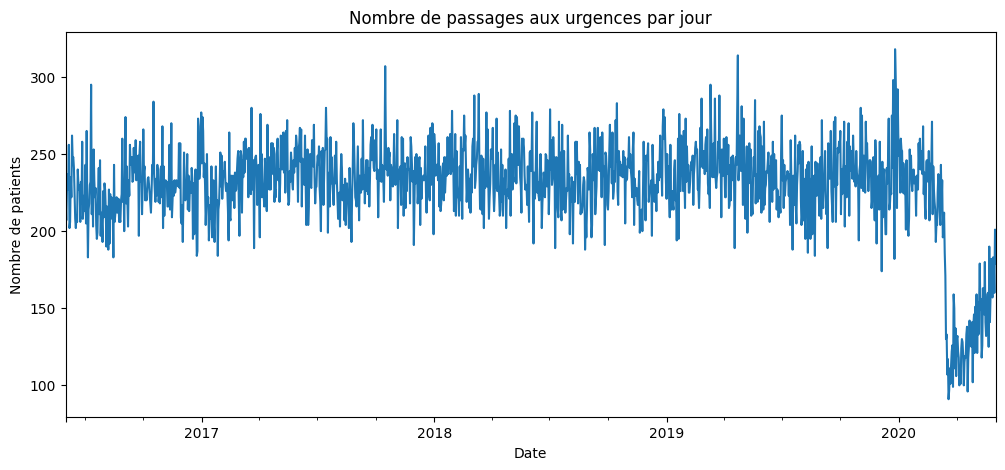

In [8]:
print("II.1.1.1 – Arrivées journalières")

arrivees_jour = (
    df_clean
    .set_index("arrivee_dt")
    .resample("D")
    .size()
)

plt.figure(figsize=(12,5))
arrivees_jour.plot()
plt.title("Nombre de passages aux urgences par jour")
plt.xlabel("Date")
plt.ylabel("Nombre de patients")
plt.show()

II.1.1.1 – Arrivées mensuelles


/tmp/ipykernel_25930/1932831801.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


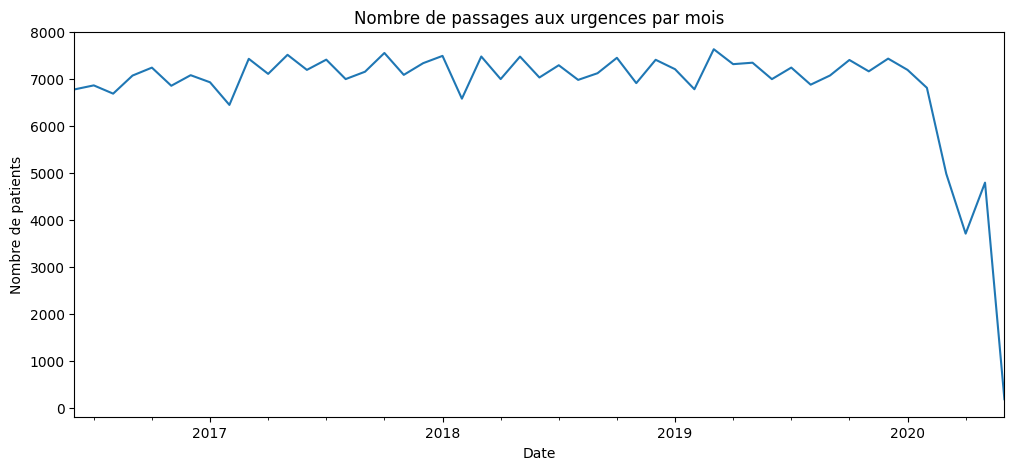

In [18]:
print("II.1.1.1 – Arrivées mensuelles")

arrivees_mois = (
    df_clean
    .set_index("arrivee_dt")
    .resample("M")
    .size()
)

plt.figure(figsize=(12,5))
arrivees_mois.plot()
plt.title("Nombre de passages aux urgences par mois")
plt.xlabel("Date")
plt.ylabel("Nombre de patients")
plt.show()

II.1.1.3 – Profil horaire moyen


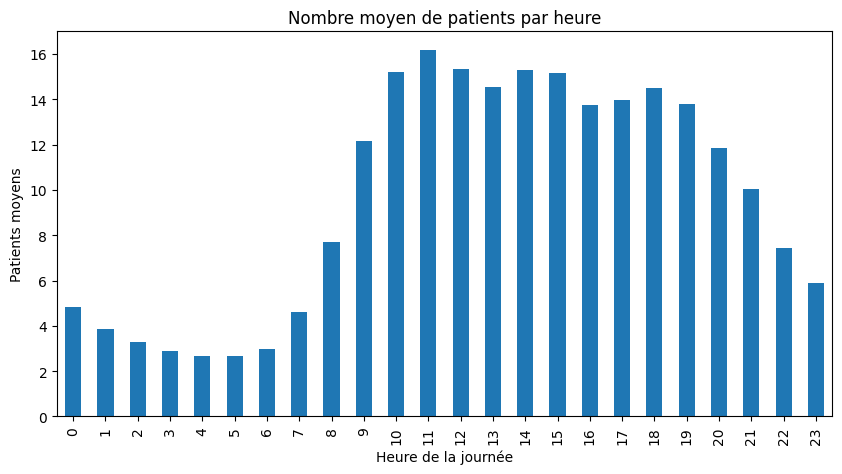

In [10]:
print("II.1.1.3 – Profil horaire moyen")

arrivees_heure = (
    df_clean
    .groupby(["jour","heure_arrivee"])
    .size()
    .groupby("heure_arrivee")
    .mean()
)

plt.figure(figsize=(10,5))
arrivees_heure.plot(kind="bar")

plt.title("Nombre moyen de patients par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Patients moyens")
plt.show()

In [20]:
print("II.1.1.5 – Analyse statistique")

print("\nStatistiques des arrivées journalières :")
print(arrivees_jour.describe())

print("\nHeure la plus chargée :")
print(arrivees_heure.idxmax(), "h avec", round(arrivees_heure.max(),2), "patients en moyenne")

II.1.1.5 – Analyse statistique

Statistiques des arrivées journalières :
count    1462.000000
mean      229.161423
std        30.364767
min        91.000000
25%       218.000000
50%       233.000000
75%       246.000000
max       318.000000
dtype: float64

Heure la plus chargée :
11 h avec 16.18 patients en moyenne


In [44]:
##

In [22]:
print("II.1.2 – Indicateur 2 : Temps d’attente avant PEC")

# Conversion en heures
df_clean["temps_attente_h"] = df_clean["temps_attente_min"] / 60

# Vérification de la variable
print("Nombre de valeurs non nulles :", df_clean["temps_attente_h"].notna().sum())

print("\nStatistiques descriptives (en heures) :")
print(df_clean["temps_attente_h"].describe())

II.1.2 – Indicateur 2 : Temps d’attente avant PEC
Nombre de valeurs non nulles : 185082

Statistiques descriptives (en heures) :
count    185082.000000
mean          1.333555
std           1.543821
min           0.000000
25%           0.283333
50%           0.716667
75%           1.850000
max          11.983333
Name: temps_attente_h, dtype: float64


II.1.2.1 – Temps d’attente moyen selon l’heure d’arrivée


<Axes: title={'center': 'Temps d’attente moyen avant PEC selon l’heure d’arrivée (heures)'}, xlabel='Heure d’arrivée', ylabel='Temps d’attente moyen (heures)'>

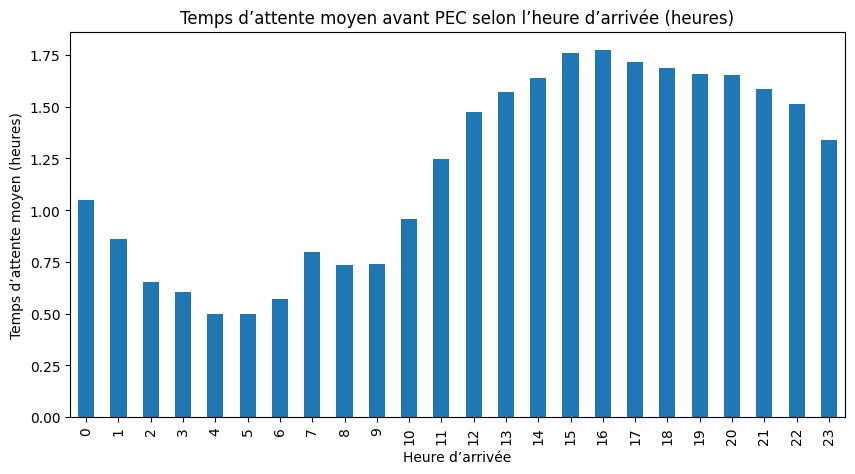

In [34]:
print("II.1.2.1 – Temps d’attente moyen selon l’heure d’arrivée")

# calcul du temps d'attente moyen (en heures) selon l'heure d'arrivée
attente_par_heure = (
    df_clean
    .groupby("heure_arrivee")["temps_attente_h"]
    .mean()
)

# graphique
attente_par_heure.plot(
    kind="bar",
    title="Temps d’attente moyen avant PEC selon l’heure d’arrivée (heures)",
    xlabel="Heure d’arrivée",
    ylabel="Temps d’attente moyen (heures)",
    figsize=(10,5)
)

II.1.2.1 – Evolution réelle du temps d’attente sur une journée
Nombre de passages ce jour : 252


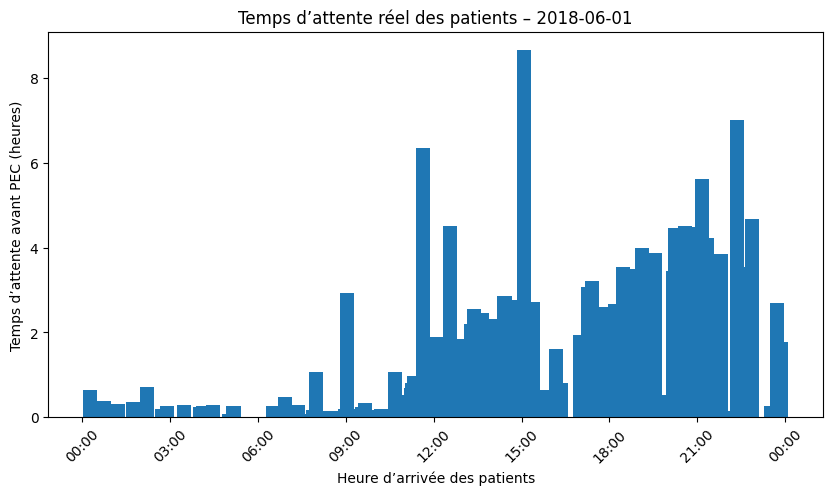

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("II.1.2.1 – Evolution réelle du temps d’attente sur une journée")

# Conversion en heures
df_clean["temps_attente_h"] = df_clean["temps_attente_min"] / 60

# Choisir un jour réel
jour_exemple = "2018-06-01"

df_jour = df_clean[df_clean["date_arrivee"] == jour_exemple].copy()

print("Nombre de passages ce jour :", len(df_jour))

# Trier par heure d'arrivée
df_jour = df_jour.sort_values("arrivee_dt")

# Graphique
plt.figure(figsize=(10,5))

plt.bar(
    df_jour["arrivee_dt"],
    df_jour["temps_attente_h"],
    width=0.02
)

plt.title(f"Temps d’attente réel des patients – {jour_exemple}")
plt.xlabel("Heure d’arrivée des patients")
plt.ylabel("Temps d’attente avant PEC (heures)")

# afficher les heures
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)
plt.show()

In [57]:
print("II.1.3 – Gravité des patients (CCMU)")

df_ccmu = df_clean.copy()

# conversion en numérique si besoin
df_ccmu['Diagnostic->Code CCMU'] = pd.to_numeric(
    df_ccmu['Diagnostic->Code CCMU'], errors='coerce'
)

II.1.3 – Gravité des patients (CCMU)


In [58]:
# effectifs
ccmu_counts = df_ccmu['Diagnostic->Code CCMU'].value_counts().sort_index()

# pourcentages
ccmu_percent = df_ccmu['Diagnostic->Code CCMU'].value_counts(normalize=True).sort_index()*100

print("Effectifs CCMU :")
print(ccmu_counts)

print("\nPourcentages CCMU :")
print(ccmu_percent.round(2))

Effectifs CCMU :
Diagnostic->Code CCMU
1.0     33288
2.0    229258
3.0     19604
4.0      2860
5.0      1730
Name: count, dtype: int64

Pourcentages CCMU :
Diagnostic->Code CCMU
1.0    11.61
2.0    79.95
3.0     6.84
4.0     1.00
5.0     0.60
Name: proportion, dtype: float64


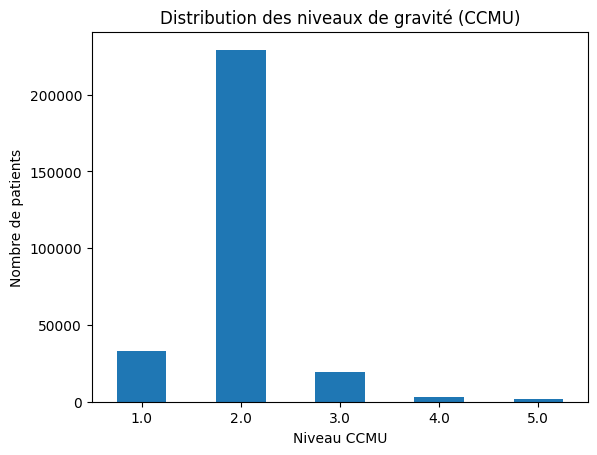

In [59]:
import matplotlib.pyplot as plt

ccmu_counts.plot(kind='bar')

plt.title("Distribution des niveaux de gravité (CCMU)")
plt.xlabel("Niveau CCMU")
plt.ylabel("Nombre de patients")
plt.xticks(rotation=0)

plt.show()

In [78]:
df_ccmu = df_clean.copy()

# conversion minutes -> heures
df_ccmu["temps_attente_h"] = df_ccmu["temps_attente_min"] / 60

# temps d'attente moyen par CCMU
attente_ccmu = df_ccmu.groupby("Diagnostic->Code CCMU")["temps_attente_h"].mean()

print(attente_ccmu)

Diagnostic->Code CCMU
1    1.293983
2    1.316876
3    1.307688
4    0.879200
5    1.707115
D    3.072861
P    1.177628
Name: temps_attente_h, dtype: float64


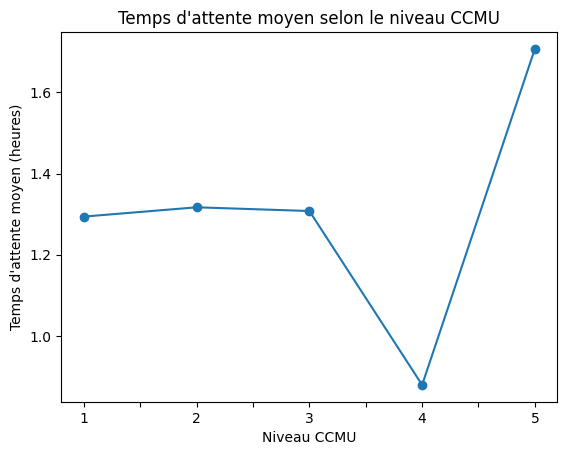

In [80]:
import matplotlib.pyplot as plt

attente_ccmu = df_ccmu[
    df_ccmu["Diagnostic->Code CCMU"].isin(['1','2','3','4','5'])
].groupby("Diagnostic->Code CCMU")["temps_attente_h"].mean()

attente_ccmu.plot(marker='o')

plt.title("Temps d'attente moyen selon le niveau CCMU")
plt.xlabel("Niveau CCMU")
plt.ylabel("Temps d'attente moyen (heures)")

plt.show()

In [83]:
print("II.1.3.2 – Analyse de la gravité CCMU")

print("Proportion CCMU 1 + 2 (%) :",
      ccmu.isin(["1", "2"]).mean() * 100)

print("Proportion CCMU ≥ 4 (%) :",
      ccmu.isin(["4", "5", "D"]).mean() * 100)

II.1.3.2 – Analyse de la gravité CCMU
Proportion CCMU 1 + 2 (%) : 91.56239101625165
Proportion CCMU ≥ 4 (%) : 1.60075329566855


In [81]:
df_ccmu["Diagnostic->Code CCMU"].unique()

array(['1', '2', 'P', '3', nan, '5', '4', 'D'], dtype=object)

In [31]:
print(df_clean.columns)

Index(['Num d'ordre', 'Date', 'Heure',
       'Informations du passage->date et heure d'arrivée',
       'Informations du passage->moyen d'arrivée', 'IAO->motif d'entrée',
       'IAO->motif de venue', 'Patient->age en année',
       'Antécédent->antécédents médicaux',
       'Antécédent->antécédents chirurgicaux',
       'Constante->Surveillances->PAS/PAD adultes (première valeur)',
       'Constante->Surveillances->FC adultes (première valeur)',
       'Constante->Surveillances->Température adultes (première valeur)',
       'Constante->Surveillances->SaO2 adultes (première valeur)',
       'Constante->Surveillances->Fréquence Respiratoire (première valeur)',
       'Diagnostic->Code CCMU', 'Localisation->Salles',
       'Localisation->date d'entrée en box', 'Anamnèse->texte',
       'IAO->observation',
       'Examens complémentaires->a des examens de biologie',
       'Examens complémentaires->a des examens de radiologie',
       'Examens complémentaires->a des examens d'échographi

In [151]:
print("II.2.1 – Prédiction du nombre de patients par jour")

import pandas as pd

# Extraction des passages par jour
df_daily = df_clean.copy()
df_daily["date"] = df_daily["arrivee_dt"].dt.date

# Comptage des patients par jour
daily_counts = df_daily.groupby("date").size().reset_index(name="nb_patients")

# Ajout de features temporelles
daily_counts["jour_annee"] = pd.to_datetime(daily_counts["date"]).dt.dayofyear
daily_counts["annee"] = pd.to_datetime(daily_counts["date"]).dt.year
daily_counts["mois"] = pd.to_datetime(daily_counts["date"]).dt.month
daily_counts["semaine"] = pd.to_datetime(daily_counts["date"]).dt.isocalendar().week.astype(int)

print("Données prêtes:", daily_counts.head())

II.2.1 – Prédiction du nombre de patients par jour
Données prêtes:          date  nb_patients  jour_annee  annee  mois  semaine
0  2016-06-01          219         153   2016     6       22
1  2016-06-02          207         154   2016     6       22
2  2016-06-03          227         155   2016     6       22
3  2016-06-04          237         156   2016     6       22
4  2016-06-05          227         157   2016     6       22


date → extraite de arrivee_dt
→ df_daily["date"] = df_daily["arrivee_dt"].dt.date
(on garde seulement la date sans l’heure)

nb_patients → nombre de patients par jour
→ groupby("date").size()
(on compte les passages chaque jour)

jour_annee → numéro du jour dans l’année (1 à 365/366)
→ dt.dayofyear

annee → année de la date
→ dt.year

mois → mois de la date (1–12)
→ dt.month

semaine → numéro de la semaine dans l’année
→ dt.isocalendar().week

lag_1 → nombre de patients la veille
→ daily_counts["lag_1"] = daily_counts["nb_patients"].shift(1)
(on décale la série d’un jour pour récupérer la valeur du jour précédent)

lag_7 → nombre de patients 7 jours avant
→ daily_counts["lag_7"] = daily_counts["nb_patients"].shift(7)
(on récupère l’activité observée une semaine auparavant)

rolling_7 → moyenne des patients sur les 7 derniers jours
→ daily_counts["rolling_7"] = daily_counts["nb_patients"].rolling(7).mean()
(on calcule la moyenne glissante sur une fenêtre de 7 jours pour capturer la tendance récente)

On utilise groupby("date") pour compter le nombre de patients par jour.
Donc les données sont organisées dans le temps avec une valeur par jour ( nbr de patients), ce qui correspond à une série temporelle journalière

In [146]:
from sklearn.model_selection import train_test_split

X = daily_counts[["jour_annee", "mois", "annee", "semaine"]]
y = daily_counts["nb_patients"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split terminé — Train:", X_train.shape, "Test:", X_test.shape)

Split terminé — Train: (1169, 4) Test: (293, 4)


1 seule série temporelle de 1169 observations.Chaque observation représente un jour donné et contient le nombre total de patients arrivés aux urgences ce jour-là ainsi que des variables temporelles et historiques (comme le jour de la semaine, le mois, les valeurs des jours précédents et les moyennes récentes) utilisées pour prédire cette activité.

In [147]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Définir le modèle de base
rf = RandomForestRegressor(random_state=42)

# Grille d’hyperparamètres
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               # validation croisée 5 folds
    scoring="neg_mean_absolute_error",  # on minimise l’erreur absolue
    n_jobs=-1           # utiliser tous les coeurs CPU
)

print("Lancement de GridSearch...")
grid_search.fit(X_train, y_train)

Lancement de GridSearch...


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error')

Le modèle Random Forest est utilisé pour prédire le nombre de patients arrivant aux urgences chaque jour à partir de variables temporelles (jour de la semaine, mois, année) ainsi que de variables issues de l’historique de l’activité, telles que le nombre de patients des jours précédents (lag_1, lag_7) et la moyenne des admissions sur les sept derniers jours (rolling_7). Le principe de ce modèle est de construire une multitude d’arbres de décision entraînés sur différentes sous-parties des données, puis de moyenner leurs prédictions afin d’obtenir un résultat plus robuste et plus précis qu’un seul arbre. Plusieurs hyperparamètres contrôlent la complexité du modèle : par exemple n_estimators (nombre d’arbres), max_depth (profondeur maximale des arbres), min_samples_split (nombre minimal d’observations pour diviser un nœud) et min_samples_leaf (nombre minimal d’observations dans une feuille). Des valeurs trop élevées de profondeur ou trop faibles de contraintes sur les feuilles peuvent conduire à du surapprentissage (overfitting), où le modèle mémorise trop les données d’entraînement. Pour sélectionner automatiquement les meilleures valeurs de ces hyperparamètres, une procédure de recherche appelée **Grid Search est utilisée : elle teste systématiquement plusieurs combinaisons de paramètres avec validation croisée et retient celle qui minimise l’erreur de prédiction.

In [148]:
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score MAE (cross-val) :", -grid_search.best_score_)

Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Meilleur score MAE (cross-val) : 15.231718844114619


In [149]:
best_model = grid_search.best_estimator_

from sklearn.metrics import mean_absolute_error, r2_score

y_pred = best_model.predict(X_test)

print("MAE test :", mean_absolute_error(y_test, y_pred))
print("R² test :", r2_score(y_test, y_pred))

MAE test : 15.152511315891783
R² test : 0.5949996235227275


Le modèle de prédiction du nombre de patients par jour obtient une MAE (erreur absolue moyenne) de 15,15 patients, ce qui signifie qu’en moyenne, les prévisions s’écartent d’environ 15 patients par rapport aux valeurs réelles. Le R² de 0,595 indique que le modèle explique environ 60 % de la variance des données, ce qui est correct mais montre qu’il reste une part importante de variation non capturée, probablement due à des fluctuations quotidiennes ou à des facteurs externes non inclus dans le modèle. Globalement, le modèle fournit des prédictions raisonnablement fiables pour observer les tendances et planifier les ressources, tout en laissant de la marge pour des améliorations futures.

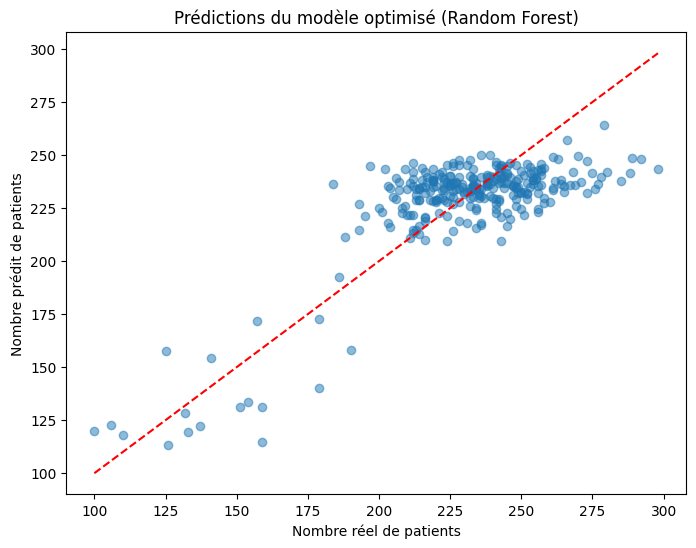

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Nombre réel de patients")
plt.ylabel("Nombre prédit de patients")
plt.title("Prédictions du modèle optimisé (Random Forest)")
plt.show()

Le scatterplot présente la relation entre le nombre réel de patients par jour et les valeurs prédites par le modèle Random Forest. La majorité des points se situe globalement autour de la diagonale représentant la prédiction parfaite, ce qui indique que le modèle parvient à capter la tendance générale de l’évolution du nombre de patients. Autrement dit, lorsque le nombre réel de patients augmente, la prédiction du modèle augmente également, montrant une corrélation cohérente entre observations et estimations. On observe néanmoins que les prédictions ont tendance à se concentrer autour d’une valeur moyenne entre environ 220 et 250, ce qui conduit le modèle à légèrement sous-estimer les journées avec des affluences plus élevées (par exemple pour des valeurs réelles supérieures à 260–280 patients, les prédictions restent souvent inférieures à 250–260 patients). Ce comportement est classique pour un modèle Random Forest, qui produit des prédictions issues de la moyenne de plusieurs arbres de décision, ce qui réduit l’influence des valeurs extrêmes. Malgré cela, les résultats obtenus restent pertinents et montrent que le modèle est capable de reproduire la dynamique globale de fréquentation, constituant ainsi une base solide pour l’analyse et l’anticipation de la charge hospitalière.

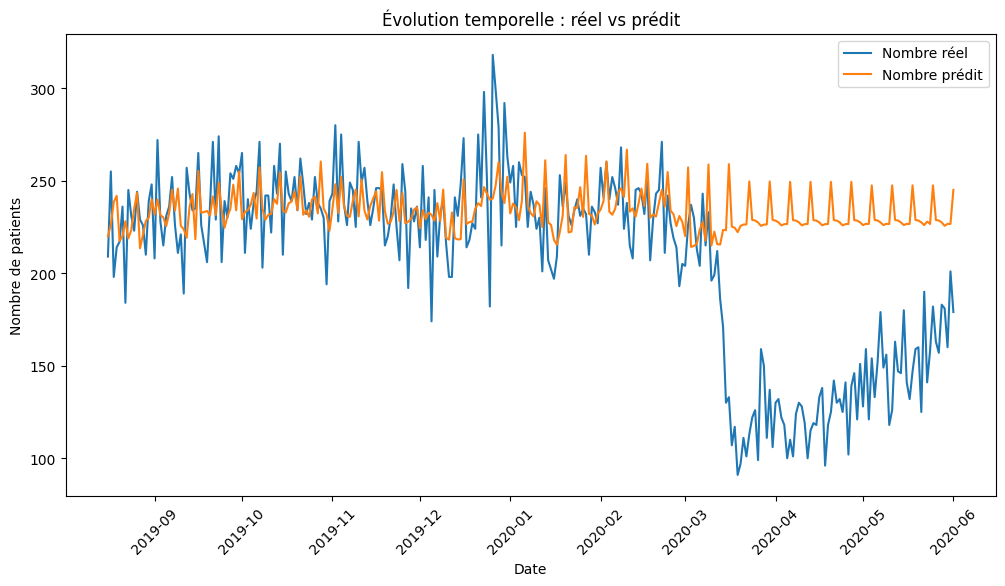

In [155]:
plt.figure(figsize=(12,6))

# On récupère les dates du test
dates_test = daily_counts.loc[X_test.index, "date"]

plt.plot(dates_test, y_test.values, label="Nombre réel")
plt.plot(dates_test, y_pred, label="Nombre prédit")

plt.xlabel("Date")
plt.ylabel("Nombre de patients")
plt.title("Évolution temporelle : réel vs prédit")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Le graphique compare le nombre réel de patients par jour (courbe bleue) avec le nombre prédit par le modèle Random Forest (courbe orange). On observe qu’avant mars 2020, les prédictions suivent globalement la tendance moyenne des passages aux urgences, avec des valeurs autour de 210–260 patients, même si le modèle lisse les variations et ne capture pas bien les pics ou les chutes brusques. En revanche, à partir de mars 2020, on remarque une chute importante du nombre réel de patients, qui descend autour de 100–150 passages par jour, alors que le modèle continue de prédire environ 230 patients. Cette différence s’explique par un événement exceptionnel dans la réalité : le début de la pandémie de COVID-19 et le premier confinement, qui ont provoqué une forte diminution des passages aux urgences car de nombreuses personnes évitaient les hôpitaux ou reportaient les consultations non urgentes. Le modèle ne peut pas anticiper cette rupture car il utilise uniquement des variables temporelles simples (jour de l’année, mois, semaine, année) et ne dispose pas d’informations sur des événements externes comme une pandémie ou des mesures sanitaires. Ainsi, ce graphique montre que le modèle parvient à capturer la tendance saisonnière normale de la fréquentation, mais qu’il reste limité face à des changements brusques liés à des facteurs exceptionnels du monde réel.

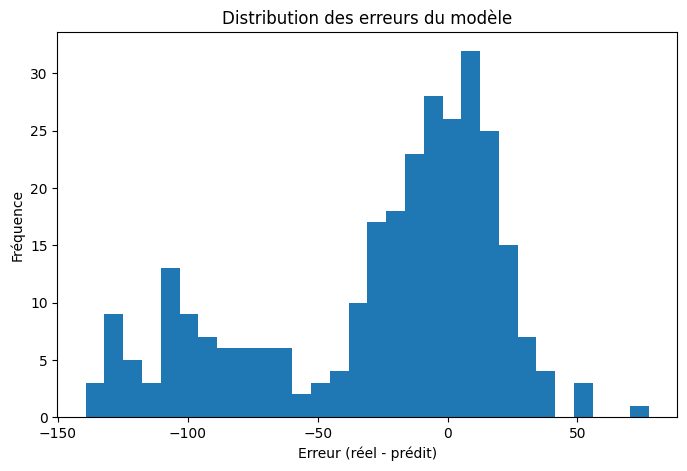

In [156]:
erreurs = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(erreurs, bins=30)
plt.xlabel("Erreur (réel - prédit)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs du modèle")
plt.show()

La distribution des erreurs est globalement centrée autour de zéro, ce qui indique que le modèle prédit de manière globalement correcte le nombre quotidien de patients. Dans un contexte hospitalier réel, cela correspond à une estimation assez fiable de l’activité quotidienne des urgences, permettant d’anticiper raisonnablement les besoins en ressources (personnel, lits, organisation du service). Toutefois, la présence de certaines erreurs plus importantes, notamment négatives, montre que le modèle peut parfois surestimer le nombre de patients. Ces écarts peuvent s’expliquer par des facteurs réels non pris en compte dans le modèle, tels que les jours fériés, les variations météorologiques, les événements exceptionnels ou les fluctuations imprévisibles de l’activité hospitalière. Malgré ces limites, le modèle parvient à capturer la tendance générale de fréquentation des urgences et constitue une base pertinente pour le développement d’outils d’aide à la décision en milieu hospitalier

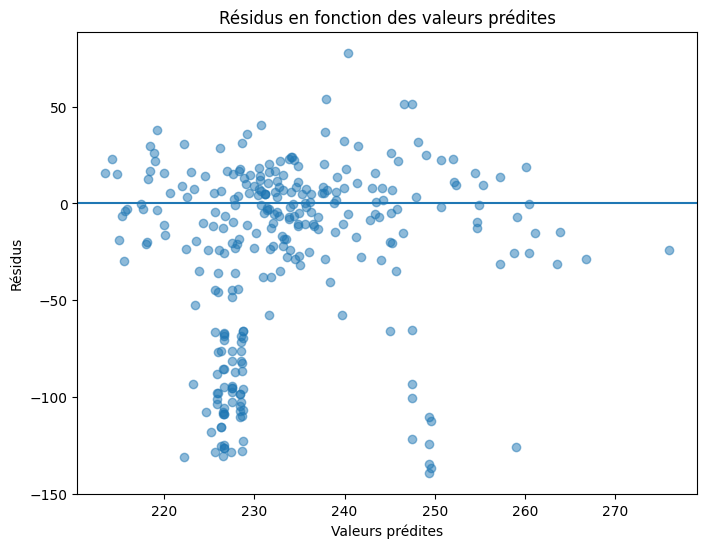

In [157]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, erreurs, alpha=0.5)
plt.axhline(0)
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus en fonction des valeurs prédites")
plt.show()

Le graphique des résidus montre que les erreurs du modèle sont globalement centrées autour de zéro, ce qui indique l’absence de biais systématique. Cependant, certaines erreurs importantes apparaissent, notamment des résidus fortement négatifs, ce qui signifie que le modèle surestime parfois le nombre réel de patients. Cela peut s’expliquer par des journées atypiques (jours fériés, perturbations hospitalières, variations imprévisibles de l’activité des urgences) que les variables temporelles utilisées dans le modèle ne permettent pas de capturer.

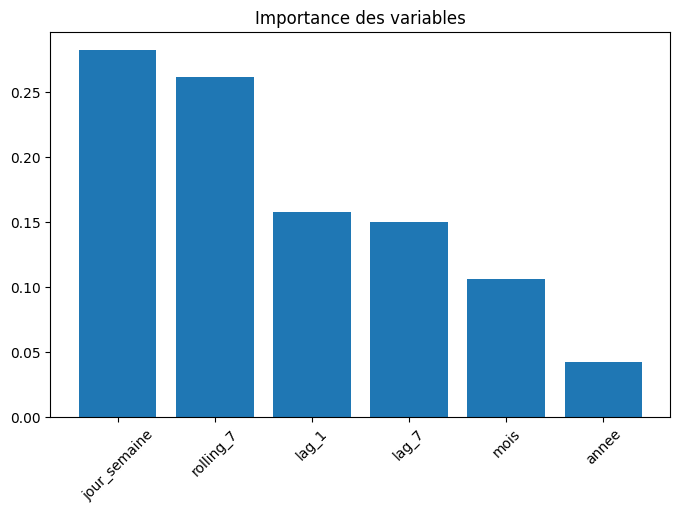

In [159]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
features = X_train.columns  # IMPORTANT

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xticks(rotation=45)
plt.title("Importance des variables")
plt.show()

Ce graphique représente l’importance des variables utilisées par le modèle pour prédire le nombre de patients aux urgences. On observe que le jour de la semaine est la variable la plus influente, ce qui s’explique facilement dans la vie réelle : l’affluence aux urgences suit souvent un rythme hebdomadaire lié aux comportements humains et à l’organisation du système de santé. La variable rolling_7 correspond à une moyenne glissante sur les 7 derniers jours, ce qui permet au modèle de capturer la tendance récente de fréquentation : si les urgences ont été très chargées durant la semaine passée, il y a de fortes chances que cette activité reste élevée, par exemple lors d’une épidémie de grippe ou d’une période de forte chaleur. Les variables lag_1 et lag_7 représentent quant à elles des valeurs passées (lag signifie « retard » ou « décalage dans le temps ») : lag_1 correspond au nombre de patients la veille et lag_7 au nombre de patients une semaine auparavant. Ces variables sont utiles car l’activité hospitalière présente souvent une continuité temporelle : une journée très chargée peut influencer la suivante, et le même jour d’une semaine précédente donne souvent une indication du niveau d’activité attendu. Les variables mois et année ont une importance plus faible, ce qui suggère que les variations à court terme et les cycles hebdomadaires expliquent davantage la fréquentation des urgences que les tendances longues. Globalement, ce résultat montre que le modèle apprend surtout les habitudes hebdomadaires et les tendances récentes de fréquentation, ce qui correspond bien à la réalité du fonctionnement des services d’urgences

Au début, j’ai testé plusieurs modèles de régression pour prédire le nombre de patients par jour, notamment la régression linéaire, et le K-Nearest Neighbors (KNN). La régression linéaire était facile à interpréter mais elle supposait une relation linéaire entre les variables et la fréquentation des urgences, ce qui ne correspond pas toujours à la réalité, la fréquentation des urgences ne suit pas une relation linéaire simple. Elle varie de manière irrégulière et parfois imprévisible à cause de nombreux facteurs comme les saisons, les jours de la semaine, les épidémies ou des événements exceptionnels comme le COVID-19. Par exemple, certains jours il peut y avoir beaucoup plus de patients que d’autres sans que cela suive une progression régulière. Le modèle KNN, quant à lui, était plus sensible au bruit dans les données et moins performant lorsque le nombre d’observations augmentait. J’ai finalement choisi d’utiliser Random Forest, car c’est un modèle d’ensemble qui combine plusieurs arbres de décision, ce qui permet de réduire le surapprentissage et d’améliorer la robustesse des prédictions. De plus, il capture bien les relations non linéaires entre les variables temporelles et le nombre de patients, tout en fournissant une importance des variables, ce qui aide à interpréter les résultats.

Intérêt de l’étude

Cette prédiction présente plusieurs intérêts opérationnels majeurs :

✔ Planification du personnel

Permet d’adapter les effectifs médicaux et paramédicaux en fonction de la charge anticipée.

✔ Anticipation des pics d’activité

Facilite la mise en place de renforts ou de circuits courts.

✔ Optimisation des ressources

Meilleure allocation des box, lits d’aval et ressources logistiques.

✔ Aide à la décision stratégique

Permet d’identifier les périodes critiques (week-ends, saisons).

Conclusion de la section

Le modèle Random Forest optimisé fournit des performances satisfaisantes (R² ≈ 0,60).

Il capture efficacement la saisonnalité hebdomadaire et les tendances globales, mais présente des limites dans la prédiction des événements exceptionnels.


In [ ]:
###CELLULES D ESSAIES

In [9]:
###Version sample

print("II.2.1 – Prédiction du nombre de patients par jour")

import pandas as pd

# Extraction des passages par jour
df_clean = pd.read_csv("df_clean.csv")
df_clean["arrivee_dt"] = pd.to_datetime(df_clean["arrivee_dt"], errors="coerce")
df_daily = df_clean.copy()
df_daily["date"] = df_daily["arrivee_dt"].dt.date

# Comptage des patients par jour
daily_counts = df_daily.groupby("date").size().reset_index(name="nb_patients")

# Ajout de features temporelles
daily_counts["jour_annee"] = pd.to_datetime(daily_counts["date"]).dt.dayofyear
daily_counts["annee"] = pd.to_datetime(daily_counts["date"]).dt.year
daily_counts["mois"] = pd.to_datetime(daily_counts["date"]).dt.month
daily_counts["semaine"] = pd.to_datetime(daily_counts["date"]).dt.isocalendar().week.astype(int)

print("Données prêtes:", daily_counts.head())

II.2.1 – Prédiction du nombre de patients par jour


/tmp/ipykernel_4471/3852469200.py:6: DtypeWarning: Columns (11,12,14,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("df_clean.csv")


Données prêtes:          date  nb_patients  jour_annee  annee  mois  semaine
0  2016-06-01          219         153   2016     6       22
1  2016-06-02          207         154   2016     6       22
2  2016-06-03          227         155   2016     6       22
3  2016-06-04          237         156   2016     6       22
4  2016-06-05          227         157   2016     6       22


In [40]:
print("Taille de df_daily :", df_daily.shape)
print("Nombre de jours comptés :", daily_counts.shape[0])

Taille de df_daily : (335034, 63)
Nombre de jours comptés : 1462


In [28]:
#daily_counts_sample = daily_counts.sample(frac=0.7, random_state=42)

X = daily_counts_sample[["jour_annee", "mois", "annee", "semaine"]]
y = daily_counts_sample["nb_patients"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split terminé — Train:", X_train.shape, "Test:", X_test.shape)

Split terminé — Train: (818, 4) Test: (205, 4)


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Définir le modèle de base
rf = RandomForestRegressor(random_state=42)

# Grille d’hyperparamètres
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,               # validation croisée 5 folds
    scoring="neg_mean_absolute_error",  # on minimise l’erreur absolue
    n_jobs=-1           # utiliser tous les coeurs CPU
)

print("Lancement de GridSearch...")
grid_search.fit(X_train, y_train)

Lancement de GridSearch...


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [30]:
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score MAE (cross-val) :", -grid_search.best_score_)

Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Meilleur score MAE (cross-val) : 15.84276003256566


MAE test : 14.59246611355009
R² test : 0.5267854579168224


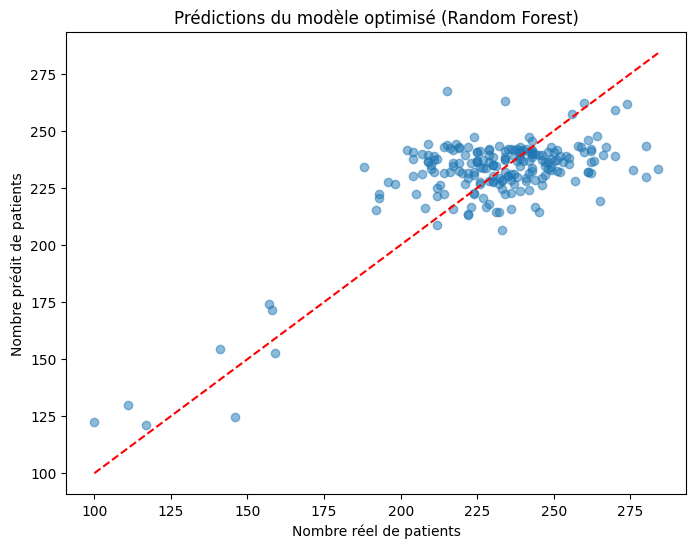

In [31]:
best_model = grid_search.best_estimator_

from sklearn.metrics import mean_absolute_error, r2_score

y_pred = best_model.predict(X_test)

print("MAE test :", mean_absolute_error(y_test, y_pred))
print("R² test :", r2_score(y_test, y_pred))


import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Nombre réel de patients")
plt.ylabel("Nombre prédit de patients")
plt.title("Prédictions du modèle optimisé (Random Forest)")
plt.show()

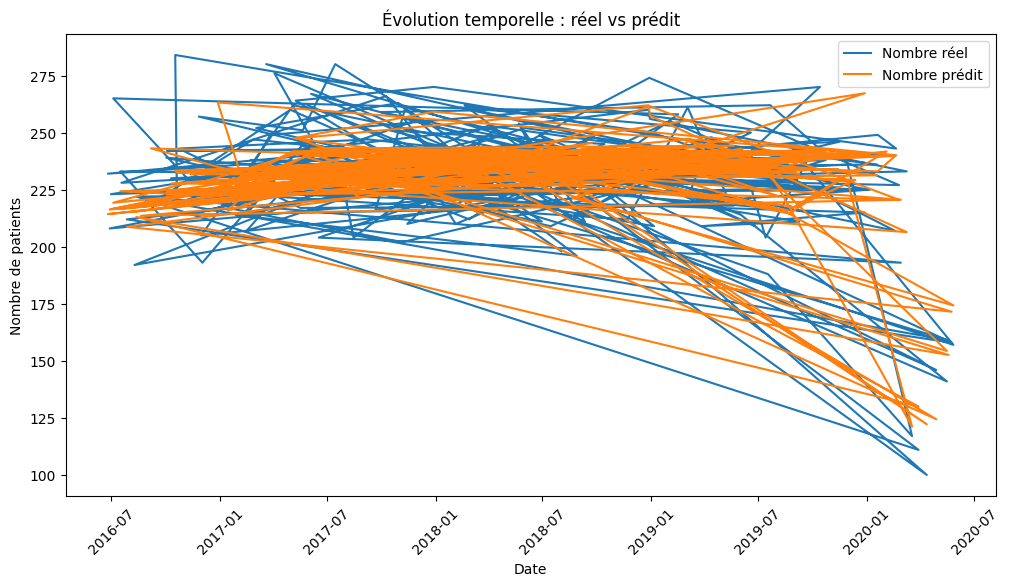

In [32]:
plt.figure(figsize=(12,6))

# On récupère les dates du test
dates_test = daily_counts.loc[X_test.index, "date"]

plt.plot(dates_test, y_test.values, label="Nombre réel")
plt.plot(dates_test, y_pred, label="Nombre prédit")

plt.xlabel("Date")
plt.ylabel("Nombre de patients")
plt.title("Évolution temporelle : réel vs prédit")
plt.legend()
plt.xticks(rotation=45)
plt.show()

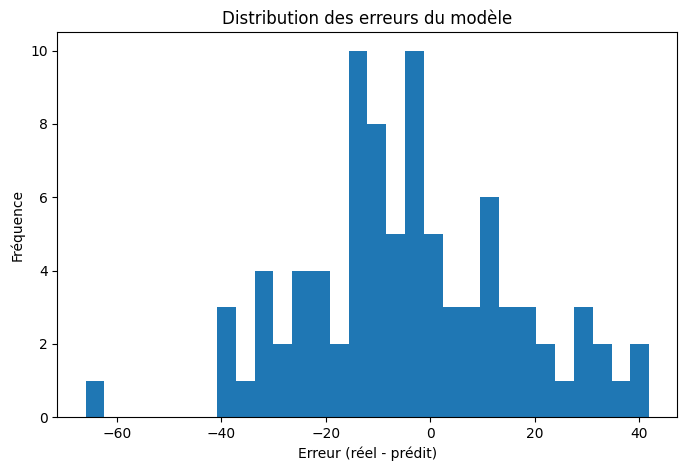

In [15]:
erreurs = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(erreurs, bins=30)
plt.xlabel("Erreur (réel - prédit)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs du modèle")
plt.show()

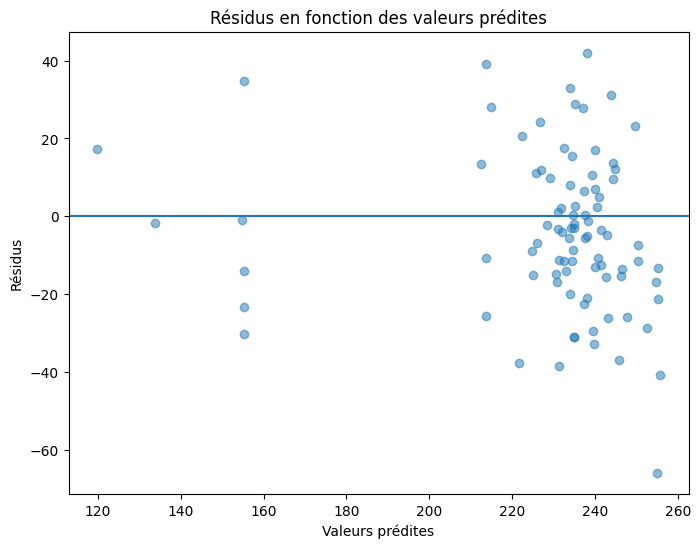

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, erreurs, alpha=0.5)
plt.axhline(0)
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus en fonction des valeurs prédites")
plt.show()


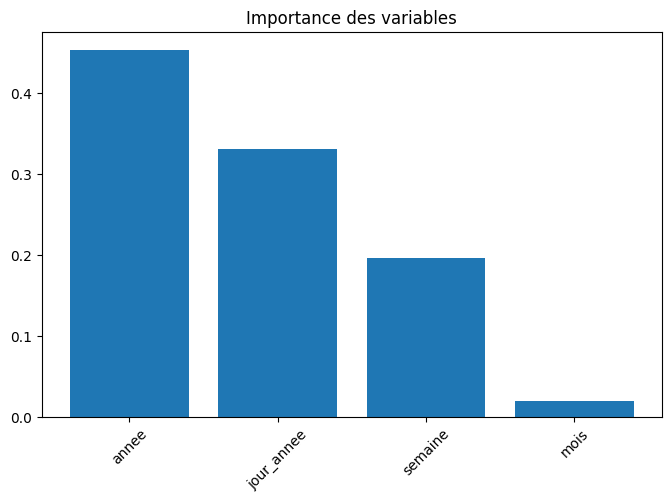

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
features = X_train.columns  # IMPORTANT

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xticks(rotation=45)
plt.title("Importance des variables")
plt.show()



In [ ]:
##CELLULES D EASSAIs

In [55]:
print(patients_par_jour.shape)
print(patients_par_jour["nb_patients"].describe())

(1455, 8)
count    1455.000000
mean      229.181443
std        30.413769
min        91.000000
25%       218.000000
50%       233.000000
75%       246.000000
max       318.000000
Name: nb_patients, dtype: float64


In [56]:
patients_par_jour.head(10)

,date_jour,nb_patients,jour_semaine,mois,annee,lag_1,lag_7,rolling_7
7,2016-06-08,206,2,6,2016,202.0,219.0,225.000000
8,2016-06-09,235,3,6,2016,206.0,207.0,223.142857
9,2016-06-10,222,4,6,2016,235.0,227.0,227.142857
10,2016-06-11,262,5,6,2016,222.0,237.0,226.428571
11,2016-06-12,247,6,6,2016,262.0,227.0,230.000000
12,2016-06-13,248,0,6,2016,247.0,256.0,232.857143
13,2016-06-14,241,1,6,2016,248.0,202.0,231.714286
14,2016-06-15,225,2,6,2016,241.0,206.0,237.285714
15,2016-06-16,208,3,6,2016,225.0,235.0,240.000000
16,2016-06-17,202,4,6,2016,208.0,222.0,236.142857


In [57]:
patients_par_jour.groupby("annee")["nb_patients"].mean()

annee
2016    227.019324
2017    236.016438
2018    236.175342
2019    236.876712
2020    180.758170
Name: nb_patients, dtype: float64

In [76]:
print(patients_par_jour["date_arrivee"].min())
print(patients_par_jour["date_arrivee"].max())

2016-06-08 00:00:00
2020-06-01 00:00:00


In [83]:
train["nb_patients"].mean(), test["nb_patients"].mean()

(234.85868725868727, 180.75816993464053)

In [89]:
patients_par_jour["nb_patients"].std()

30.413768543788272

In [94]:
patients_par_jour["nb_patients"].iloc[-200:].mean()
patients_par_jour["nb_patients"].iloc[:-200].mean()

234.95048701298703

In [43]:
print("II.2.2 – Prédiction de la durée du traitement (temps_sejour_h)")

import pandas as pd

df_clean = pd.read_csv("df_clean.csv")

II.2.2 – Prédiction de la durée du traitement (temps_sejour_h)


/tmp/ipykernel_4120/3939164544.py:5: DtypeWarning: Columns (11,12,14,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("df_clean.csv")


In [2]:
print(df_clean.columns)

Index(['Num d'ordre', 'Date', 'Heure',
       'Informations du passage->date et heure d'arrivée',
       'Informations du passage->moyen d'arrivée', 'IAO->motif d'entrée',
       'IAO->motif de venue', 'Patient->age en année',
       'Antécédent->antécédents médicaux',
       'Antécédent->antécédents chirurgicaux',
       'Constante->Surveillances->PAS/PAD adultes (première valeur)',
       'Constante->Surveillances->FC adultes (première valeur)',
       'Constante->Surveillances->Température adultes (première valeur)',
       'Constante->Surveillances->SaO2 adultes (première valeur)',
       'Constante->Surveillances->Fréquence Respiratoire (première valeur)',
       'Diagnostic->Code CCMU', 'Localisation->Salles',
       'Localisation->date d'entrée en box', 'Anamnèse->texte',
       'IAO->observation',
       'Examens complémentaires->a des examens de biologie',
       'Examens complémentaires->a des examens de radiologie',
       'Examens complémentaires->a des examens d'échographi

In [22]:
print("Train R² :", best_model.score(X_train, y_train))
print("Test R² :", best_model.score(X_test, y_test))

Train R² : 0.4450411950525175
Test R² : 0.4226019238957823


In [23]:
import numpy as np
baseline = np.mean(y_train)
y_pred_base = np.full_like(y_test, baseline)

from sklearn.metrics import r2_score
print("Baseline R² :", r2_score(y_test, y_pred_base))

Baseline R² : -3.941810496232989e-06


In [25]:
print("Variance y :", np.var(y))
print("Std y :", np.std(y))

Variance y : 76.61856928247883
Std y : 8.753203372621867


In [78]:
print("Nombre de lignes :", len(df_model))
print("NaN delay_box :", df_model["delay_box_h"].isna().sum())
print("NaN delay_pec :", df_model["delay_pec_h"].isna().sum())
print("NaN target :", df_model["temps_sejour_h"].isna().sum())

print("Stats durée séjour :")
print(df_model["temps_sejour_h"].describe())

print("Stats delay_box :")
print(df_model["delay_box_h"].describe())

Nombre de lignes : 171646
NaN delay_box : 0
NaN delay_pec : 0
NaN target : 0
Stats durée séjour :
count    171646.000000
mean          8.924116
std           7.611191
min           0.083333
25%           4.366667
50%           6.566667
75%          10.133333
max          48.000000
Name: temps_sejour_h, dtype: float64
Stats delay_box :
count    171646.000000
mean          1.381609
std           1.930515
min           0.000000
25%           0.283333
50%           0.733333
75%           1.866667
max         241.366667
Name: delay_box_h, dtype: float64


In [79]:
df_short = df_model[df_model["temps_sejour_h"] < 15]

print("Nouvelle taille :", len(df_short))

Nouvelle taille : 147652


Répartition classes :
long_sejour
0    0.773408
1    0.226592
Name: proportion, dtype: float64
GridSearch en cours...
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Accuracy : 0.8176590812030993
AUC ROC : 0.8305323557042935

Classification report :
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     50708
           1       0.66      0.40      0.50     14856

    accuracy                           0.82     65564
   macro avg       0.75      0.67      0.69     65564
weighted avg       0.80      0.82      0.80     65564

Matrice de confusion :
[[47677  3031]
 [ 8924  5932]]


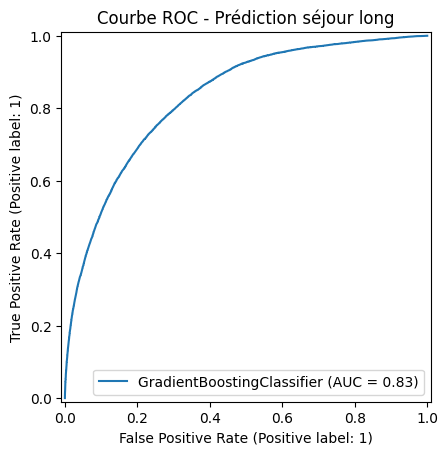

In [81]:
# GradientBoostingClassifier TOUTE PREMIERE VERSION   ###SEJOURS
# 1️⃣ IMPORTS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# =====================================================
# 2️⃣ PREPARATION DONNEES
# =====================================================

df_model = df_clean.copy()

# Conversion datetime
cols_datetime = ["arrivee_dt", "box_dt", "pec_dt", "sortie_dt"]

for col in cols_datetime:
    df_model[col] = pd.to_datetime(df_model[col], errors="coerce")

df_model = df_model.dropna(subset=["temps_sejour_h"])

# Filtrer durée réaliste
df_model = df_model[
    (df_model["temps_sejour_h"] > 0) &
    (df_model["temps_sejour_h"] < 48)
]

# =====================================================
# 3️⃣ CREATION VARIABLE CIBLE (OPTIMALE)
# =====================================================

# Séjour long >= 8h
df_model["long_sejour"] = (df_model["temps_sejour_h"] >= 8).astype(int)

print("Répartition classes :")
print(df_model["long_sejour"].value_counts(normalize=True))

# =====================================================
# 4️⃣ VARIABLES PREDICTIVES (UNIQUEMENT CONNUES EN COURS DE SEJOUR)
# =====================================================

df_model["hospitalisation"] = (
    df_model["Orientation->type d'orientation"]
    .astype(str)
    .str.contains("HOSP", case=False)
    .astype(int)
)

features = [
    "Patient->age en année",
    "heure_arrivee",
    "mois",
    "Diagnostic->Code CCMU",
    "Examens complémentaires->a des examens de scanner",
    "Examens complémentaires->a des examens de biologie",
    "Examens complémentaires->a des examens de radiologie",
    "hospitalisation"
]

X = df_model[features]
y = df_model["long_sejour"]

X = pd.get_dummies(X, drop_first=True)

# =====================================================
# 5️⃣ TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 6️⃣ MODELE OPTIMISE
# =====================================================

clf = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators": [150, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4]
}

grid = GridSearchCV(
    clf,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

print("GridSearch en cours...")
grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)

best_model = grid.best_estimator_

# =====================================================
# 7️⃣ EVALUATION
# =====================================================

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("AUC ROC :", roc_auc_score(y_test, y_proba))

print("\nClassification report :")
print(classification_report(y_test, y_pred))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

# =====================================================
# 8️⃣ COURBE ROC
# =====================================================

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Courbe ROC - Prédiction séjour long")
plt.show()

/tmp/ipykernel_4471/2295889672.py:22: DtypeWarning: Columns (11,12,14,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("df_clean.csv")


Taille dataset : 327819
Répartition classes :
long_sejour
0    0.773408
1    0.226592
Name: proportion, dtype: float64
Entraînement en cours...
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

=== RESULTATS SEUIL 0.5 ===
Accuracy : 0.8176590812030993
AUC ROC : 0.8305323557042935
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     50708
           1       0.66      0.40      0.50     14856

    accuracy                           0.82     65564
   macro avg       0.75      0.67      0.69     65564
weighted avg       0.80      0.82      0.80     65564

Matrice de confusion :
[[47677  3031]
 [ 8924  5932]]

=== RESULTATS SEUIL AJUSTE : 0.3 ===
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     50708
           1       0.52      0.65      0.58     14856

    accuracy                           0.79     65564
   macro avg       0.71      0.74      0.72     

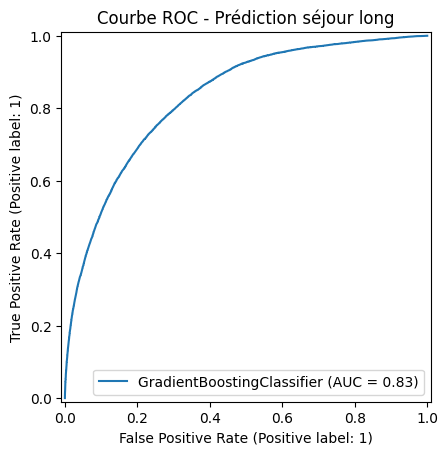


Importance des variables :
Examens complémentaires->a des examens de biologie_oui      0.447921
Examens complémentaires->a des examens de scanner_oui       0.256387
Diagnostic->Code CCMU_2                                     0.096943
Patient->age en année                                       0.088009
heure_arrivee                                               0.031026
Examens complémentaires->a des examens de radiologie_oui    0.030637
Diagnostic->Code CCMU_3                                     0.018523
mois                                                        0.013568
Diagnostic->Code CCMU_4                                     0.007397
Diagnostic->Code CCMU_5                                     0.004572
Diagnostic->Code CCMU_P                                     0.003099
Diagnostic->Code CCMU_D                                     0.001918
hospitalisation                                             0.000000
dtype: float64


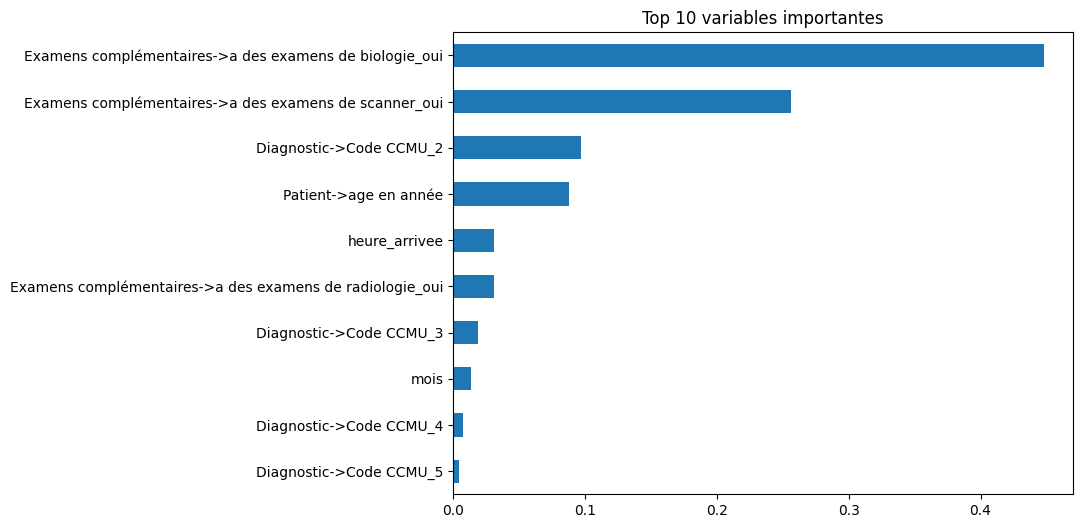

In [2]:
# GradientBoostingClassifier AVEC SEUIL 0.3 & 0.5  SUR TOUTE LA BASE   ###SEJOURS

# 1️⃣ IMPORTS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# =====================================================
# 2️⃣ PREPARATION DES DONNEES
# =====================================================
df_clean = pd.read_csv("df_clean.csv")

df_model = df_clean.copy()

# Conversion datetime
cols_datetime = ["arrivee_dt", "box_dt", "pec_dt", "sortie_dt"]
for col in cols_datetime:
    df_model[col] = pd.to_datetime(df_model[col], errors="coerce")

# Supprimer durée manquante
df_model = df_model.dropna(subset=["temps_sejour_h"])

# Filtrer valeurs réalistes
df_model = df_model[
    (df_model["temps_sejour_h"] > 0) &
    (df_model["temps_sejour_h"] < 48)
]

print("Taille dataset :", len(df_model))

# =====================================================
# 3️⃣ CREATION VARIABLE CIBLE
# =====================================================

# Séjour long >= 8h
df_model["long_sejour"] = (df_model["temps_sejour_h"] >= 8).astype(int)

print("Répartition classes :")
print(df_model["long_sejour"].value_counts(normalize=True))

# =====================================================
# 4️⃣ FEATURES
# =====================================================

df_model["hospitalisation"] = (
    df_model["Orientation->type d'orientation"]
    .astype(str)
    .str.contains("HOSP", case=False)
    .astype(int)
)

features = [
    "Patient->age en année",
    "heure_arrivee",
    "mois",
    "Diagnostic->Code CCMU",
    "Examens complémentaires->a des examens de scanner",
    "Examens complémentaires->a des examens de biologie",
    "Examens complémentaires->a des examens de radiologie",
    "hospitalisation"
]

X = df_model[features]
y = df_model["long_sejour"]

# Encodage catégoriel
X = pd.get_dummies(X, drop_first=True)

# =====================================================
# 5️⃣ TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 6️⃣ GRIDSEARCH OPTIMISE
# =====================================================

clf = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators": [200],
    "learning_rate": [0.1],
    "max_depth": [4]
}

grid = GridSearchCV(
    clf,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

print("Entraînement en cours...")
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Meilleurs paramètres :", grid.best_params_)

# =====================================================
# 7️⃣ EVALUATION STANDARD
# =====================================================

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== RESULTATS SEUIL 0.5 ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("AUC ROC :", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

# =====================================================
# 8️⃣ AJUSTEMENT DU SEUIL (OPTIMAL)
# =====================================================

threshold = 0.30
y_pred_adjusted = (y_proba >= threshold).astype(int)

print("\n=== RESULTATS SEUIL AJUSTE :", threshold, "===")
print(classification_report(y_test, y_pred_adjusted))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_adjusted))

# =====================================================
# 9️⃣ COURBE ROC
# =====================================================

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Courbe ROC - Prédiction séjour long")
plt.show()

# =====================================================
# 🔟 IMPORTANCE DES VARIABLES
# =====================================================

importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nImportance des variables :")
print(importances)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 variables importantes")
plt.show()

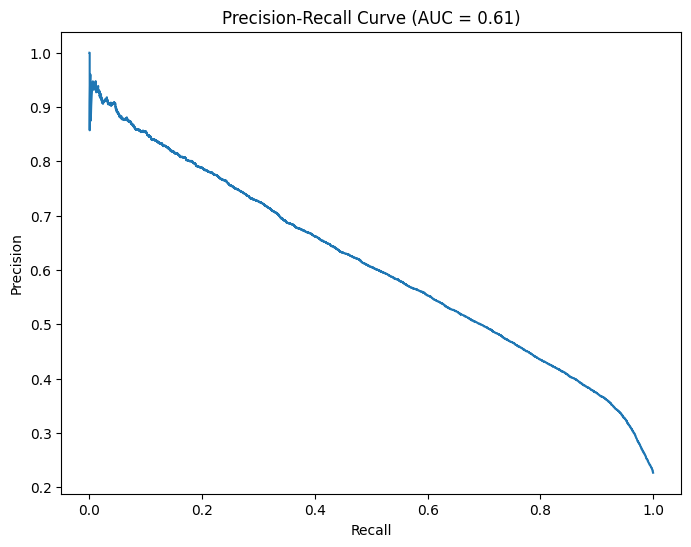

In [83]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.2f})")
plt.show()

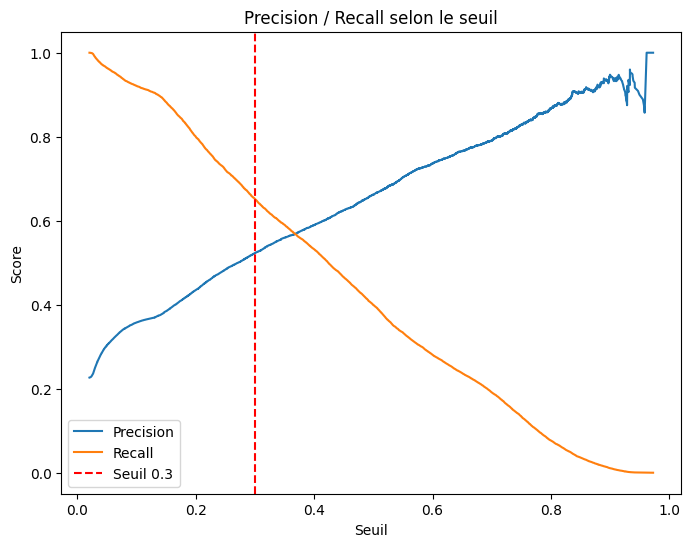

In [84]:
plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(x=0.3, color='r', linestyle='--', label="Seuil 0.3")
plt.xlabel("Seuil")
plt.ylabel("Score")
plt.legend()
plt.title("Precision / Recall selon le seuil")
plt.show()

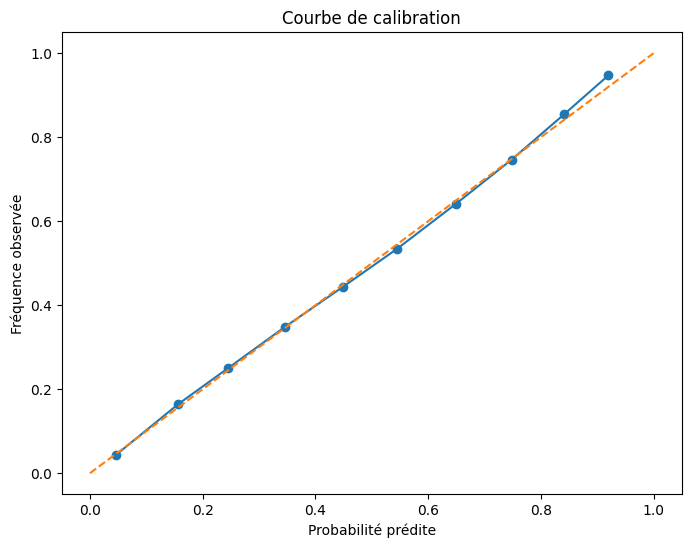

In [85]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Probabilité prédite")
plt.ylabel("Fréquence observée")
plt.title("Courbe de calibration")
plt.show()

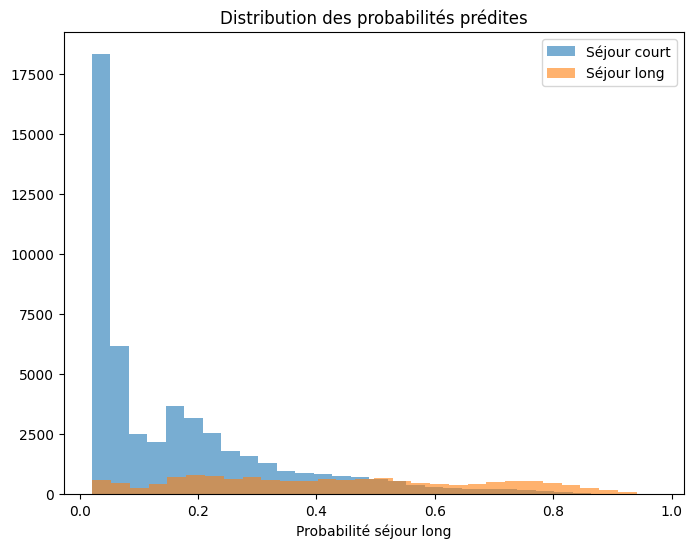

In [86]:
plt.figure(figsize=(8,6))
plt.hist(y_proba[y_test == 0], bins=30, alpha=0.6, label="Séjour court")
plt.hist(y_proba[y_test == 1], bins=30, alpha=0.6, label="Séjour long")
plt.legend()
plt.title("Distribution des probabilités prédites")
plt.xlabel("Probabilité séjour long")
plt.show()

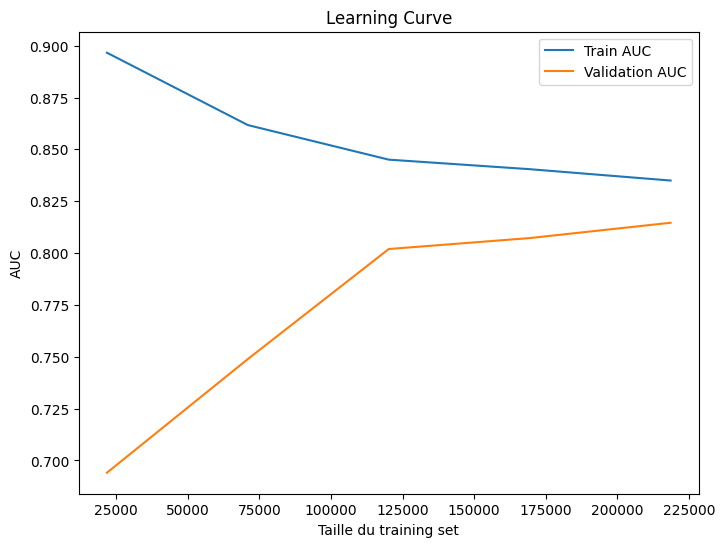

In [87]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y,
    cv=3,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Train AUC")
plt.plot(train_sizes, test_mean, label="Validation AUC")
plt.xlabel("Taille du training set")
plt.ylabel("AUC")
plt.legend()
plt.title("Learning Curve")
plt.show()

1. Prédiction de la durée du traitement (séjour long)
1.1. Description du jeu de données

L’analyse repose sur un dataset de 327 819 passages aux urgences.
La variable cible est une variable binaire :

0 : séjour court

1 : séjour long

Répartition des classes :

Séjour court : 77,34 %

Séjour long : 22,66 %

Le jeu de données présente donc un déséquilibre modéré, avec environ un patient sur cinq en séjour long.

Le modèle utilisé est un Gradient Boosting Classifier, optimisé par GridSearch avec validation croisée.

Meilleurs hyperparamètres :

learning_rate = 0.1

max_depth = 4

n_estimators = 200

2. Les courbes

Plusieurs courbes ont été utilisées pour analyser la performance et le comportement du modèle :

Courbe ROC

Courbe Precision-Recall

Courbe Precision/Recall selon le seuil

Courbe de calibration

Distribution des probabilités prédites

Learning curve

Importance des variables

3. Analyse des performances
3.1. Performance globale (seuil 0.5)

Accuracy : 0.818
AUC ROC : 0.83

L’AUC à 0.83 indique une bonne capacité de discrimination entre séjours courts et longs.

Matrice de confusion (seuil 0.5) :

Le modèle détecte très bien les séjours courts (recall = 0.94)

Il détecte moins bien les séjours longs (recall = 0.40)

Cela signifie qu’avec le seuil classique de 0.5, le modèle est conservateur :
il privilégie la réduction des faux positifs mais manque des séjours longs.

3.2. Ajustement du seuil (0.3)

En abaissant le seuil à 0.3 :

Recall séjour long passe de 0.40 → 0.65

Precision séjour long devient 0.52

Accuracy globale baisse légèrement (0.79)

Interprétation :

Le modèle devient plus sensible à la détection des séjours longs, ce qui est préférable dans un contexte hospitalier où il est plus coûteux de ne pas anticiper un séjour long.

Le choix du seuil dépend donc de l’objectif organisationnel :

Optimisation logistique → seuil 0.3 préférable

Minimisation des erreurs globales → seuil 0.5 acceptable

3.3. Courbe ROC

L’AUC de 0.83 montre :

Bonne séparation statistique des classes

Capacité prédictive stable

Performance robuste sur l’ensemble des seuils

Le modèle n’est pas aléatoire (AUC >> 0.5).

3.4. Courbe Precision-Recall

AUC PR = 0.61

Étant donné le déséquilibre des classes (22 % de séjours longs), cette courbe est particulièrement pertinente.

On observe :

Bonne précision pour faibles niveaux de recall

Diminution progressive de la précision lorsque le recall augmente

Cela reflète le compromis classique entre sensibilité et spécificité.

3.5. Courbe Precision/Recall selon le seuil

Cette courbe montre clairement :

La précision augmente quand le seuil augmente

Le recall diminue quand le seuil augmente

Le seuil 0.3 représente un compromis opérationnel intéressant, car il améliore la détection des séjours longs sans dégrader excessivement la précision.

3.6. Courbe de calibration

La courbe de calibration est proche de la diagonale.

Cela signifie que :

Les probabilités prédites sont bien calibrées

Une probabilité prédite de 0.7 correspond réellement à environ 70 % de séjours longs

C’est un point très important pour une utilisation clinique.

3.7. Distribution des probabilités

On observe une séparation partielle entre :

Les séjours courts (concentrés vers 0–0.3)

Les séjours longs (distribution plus étalée vers 0.4–0.9)

La séparation n’est pas parfaite, ce qui explique que le Rappel ne soit pas maximal.

3.8. Learning Curve

La learning curve montre :

AUC train ≈ 0.84

AUC validation ≈ 0.81

Les deux courbes convergent.

Interprétation :

Pas de surapprentissage majeur

Modèle relativement stable

La performance semble plafonner → ajouter plus de données n’améliorera pas drastiquement la performance

4. Importance des variables

Top variables explicatives :

Examens complémentaires – Biologie (0.448)

Scanner (0.256)

Code CCMU 2

Âge

Heure d’arrivée

Radiologie

Interprétation clinique :

La prescription d’examens complémentaires est le facteur le plus prédictif d’un séjour long.

Le scanner est fortement associé aux séjours prolongés.

Le niveau de gravité (CCMU) influence la durée.

L’âge est un facteur important.

L’heure d’arrivée peut refléter la charge du service.

La variable hospitalisation a une importance nulle car elle est probablement redondante ou corrélée indirectement avec d’autres variables.

5. Intérêt de l’étude

Cette modélisation présente un intérêt organisationnel majeur :

Anticipation des lits nécessaires

Optimisation des flux patients

Allocation dynamique des ressources médicales

Réduction du temps d’attente global

Amélioration de la planification des examens

L’ajustement du seuil permet une adaptation aux objectifs stratégiques :

Priorité à la sécurité → seuil plus bas

Priorité à l’efficacité globale → seuil standard

6. Conclusion scientifique

Le modèle Gradient Boosting optimisé permet :

Une discrimination robuste (AUC 0.83)

Une calibration fiable

Une interprétabilité acceptable via l’importance des variables

Une adaptation au contexte via le réglage du seuil

Bien que la prédiction ne soit pas parfaite, elle est suffisamment performante pour être intégrée dans un outil d’aide à la décision hospitalier.

/tmp/ipykernel_4471/10396371.py:24: DtypeWarning: Columns (11,12,14,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("df_clean.csv")


Taille dataset : 48899
Répartition classes :
long_sejour
0    0.775067
1    0.224933
Name: proportion, dtype: float64
Entraînement en cours...
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

=== RESULTATS SEUIL 0.5 ===
Accuracy : 0.8115541922290389
AUC ROC : 0.8208574598224994
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      7580
           1       0.64      0.37      0.47      2200

    accuracy                           0.81      9780
   macro avg       0.74      0.65      0.68      9780
weighted avg       0.79      0.81      0.79      9780

Matrice de confusion :
[[7124  456]
 [1387  813]]

=== RESULTATS SEUIL AJUSTE : 0.3 ===
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      7580
           1       0.50      0.64      0.56      2200

    accuracy                           0.78      9780
   macro avg       0.69      0.73      0.71      9780

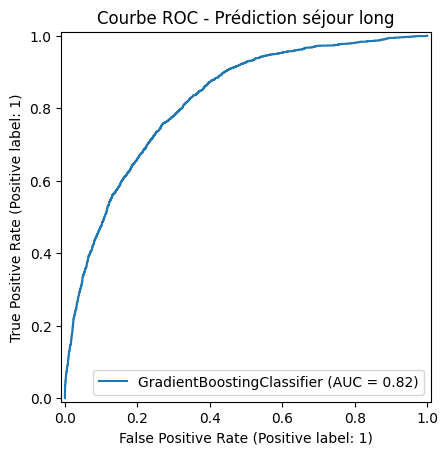


Importance des variables :
Examens complémentaires->a des examens de biologie_oui      0.408358
Examens complémentaires->a des examens de scanner_oui       0.240444
Patient->age en année                                       0.111433
Diagnostic->Code CCMU_2                                     0.098163
heure_arrivee                                               0.046552
mois                                                        0.028599
Examens complémentaires->a des examens de radiologie_oui    0.028401
Diagnostic->Code CCMU_3                                     0.021648
Diagnostic->Code CCMU_4                                     0.005147
Diagnostic->Code CCMU_5                                     0.004635
Diagnostic->Code CCMU_P                                     0.004600
Diagnostic->Code CCMU_D                                     0.002020
hospitalisation                                             0.000000
dtype: float64


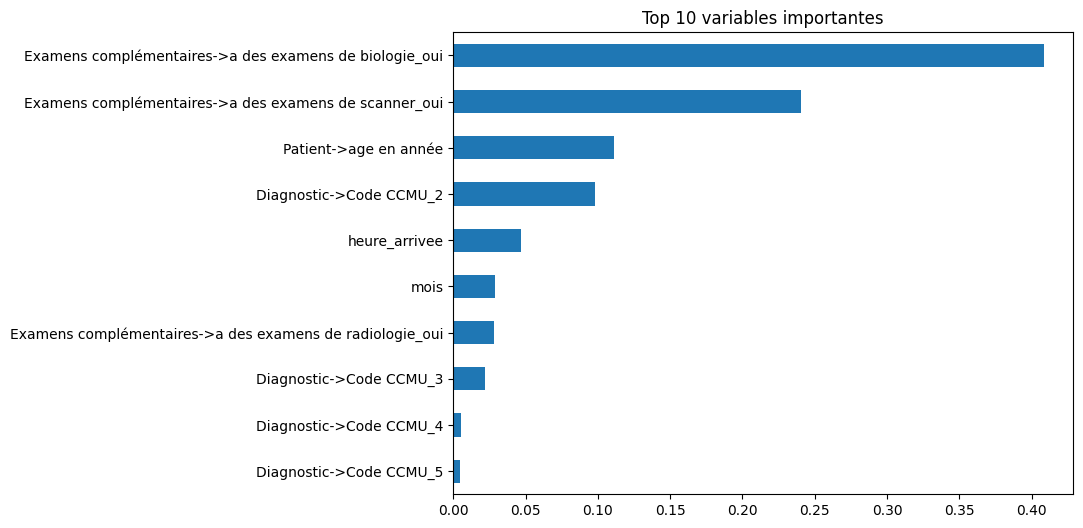

In [43]:
# # GradientBoostingClassifier AVEC SEUIL 0.3 & 0.5  SUR UN ECHANTILLON    ###SEJOURS

# 1️⃣ IMPORTS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# =====================================================
# 2️⃣ PREPARATION DES DONNEES

# =====================================================

df_clean = pd.read_csv("df_clean.csv")
df_model = df_clean.copy()

#  ECHANTILLON 
df_model = df_model.sample(n=50000, random_state=42)

# Conversion datetime
cols_datetime = ["arrivee_dt", "box_dt", "pec_dt", "sortie_dt"]
for col in cols_datetime:
    df_model[col] = pd.to_datetime(df_model[col], errors="coerce")

# Supprimer durée manquante
df_model = df_model.dropna(subset=["temps_sejour_h"])

# Filtrer valeurs réalistes
df_model = df_model[
    (df_model["temps_sejour_h"] > 0) &
    (df_model["temps_sejour_h"] < 48)
]

print("Taille dataset :", len(df_model))

# =====================================================
# 3️⃣ CREATION VARIABLE CIBLE
# =====================================================

# Séjour long >= 8h
df_model["long_sejour"] = (df_model["temps_sejour_h"] >= 8).astype(int)

print("Répartition classes :")
print(df_model["long_sejour"].value_counts(normalize=True))

# =====================================================
# 4️⃣ FEATURES
# =====================================================

df_model["hospitalisation"] = (
    df_model["Orientation->type d'orientation"]
    .astype(str)
    .str.contains("HOSP", case=False)
    .astype(int)
)

features = [
    "Patient->age en année",
    "heure_arrivee",
    "mois",
    "Diagnostic->Code CCMU",
    "Examens complémentaires->a des examens de scanner",
    "Examens complémentaires->a des examens de biologie",
    "Examens complémentaires->a des examens de radiologie",
    "hospitalisation"
]

X = df_model[features]
y = df_model["long_sejour"]

# Encodage catégoriel
X = pd.get_dummies(X, drop_first=True)

# =====================================================
# 5️⃣ TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 6️⃣ GRIDSEARCH OPTIMISE
# =====================================================

clf = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators": [200],
    "learning_rate": [0.1],
    "max_depth": [4]
}

grid = GridSearchCV(
    clf,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

print("Entraînement en cours...")
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Meilleurs paramètres :", grid.best_params_)

# =====================================================
# 7️⃣ EVALUATION STANDARD
# =====================================================

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== RESULTATS SEUIL 0.5 ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("AUC ROC :", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

# =====================================================
# 8️⃣ AJUSTEMENT DU SEUIL (OPTIMAL)
# =====================================================

threshold = 0.30
y_pred_adjusted = (y_proba >= threshold).astype(int)

print("\n=== RESULTATS SEUIL AJUSTE :", threshold, "===")
print(classification_report(y_test, y_pred_adjusted))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_adjusted))

# =====================================================
# 9️⃣ COURBE ROC
# =====================================================

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Courbe ROC - Prédiction séjour long")
plt.show()

# =====================================================
# 🔟 IMPORTANCE DES VARIABLES
# =====================================================

importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nImportance des variables :")
print(importances)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 variables importantes")
plt.show()

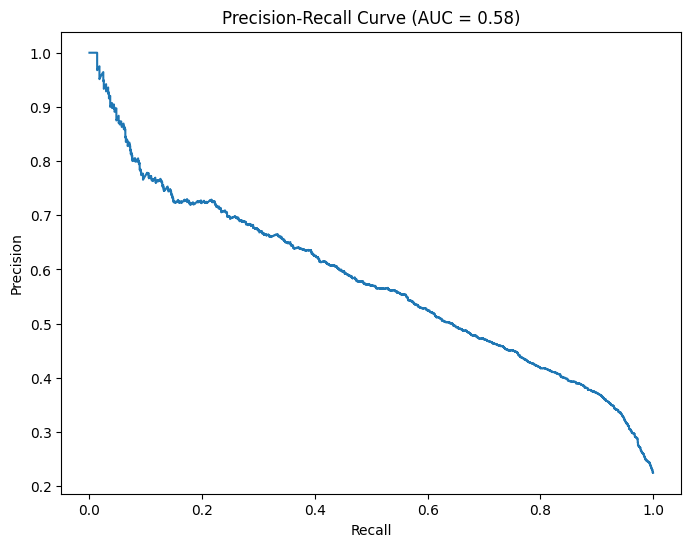

In [44]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.2f})")
plt.show()

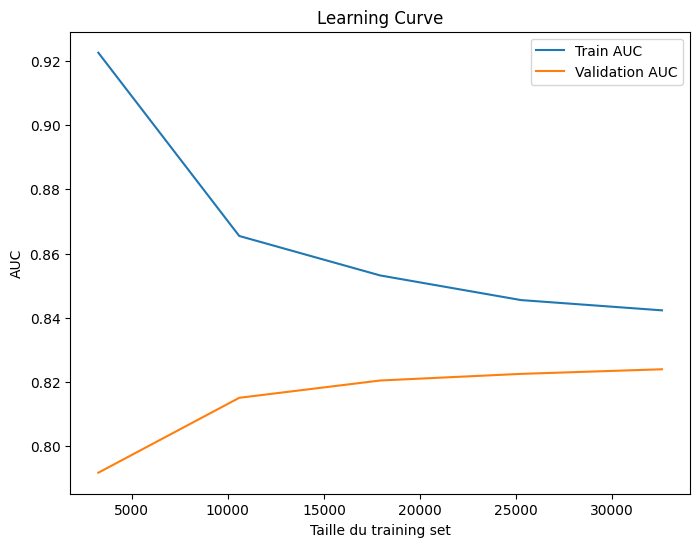

In [45]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y,
    cv=3,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Train AUC")
plt.plot(train_sizes, test_mean, label="Validation AUC")
plt.xlabel("Taille du training set")
plt.ylabel("AUC")
plt.legend()
plt.title("Learning Curve")
plt.show()

Les performances sur des échantillon ou la base complète ont été très similaires, indiquant que le modèle capture bien les relations stables. En comme en statistique, plus l’échantillon est grand, plus la précision est fiable ; nous avons donc choisi d’utiliser la base complète, surtout en ayant des données hétérogènes.

La durée de traitement correspond à la différence entre l’heure de sortie des urgences et l’heure de première prise en charge. Afin de faciliter l’analyse, cette variable a été catégorisée en deux classes : durée courte (< 3 heures) et durée longue (≥ 3 heures). Ce seuil de 3 heures ne constitue pas un standard officiel, mais il a été choisi car il est proche de la durée médiane de passage aux urgences en France, estimée à environ 3 heures selon les données publiées par la Direction de la recherche, des études, de l’évaluation et des statistiques (DREES). Ce choix permet ainsi de distinguer les prises en charge relativement rapides des passages plus prolongés aux urgences.

Ces métriques (MAE, SMAPE, MASE, R²) sont utilisées pour des problèmes de régression, lorsque le modèle prédit une valeur continue. Dans mon cas, le modèle prédit une classe binaire (séjour court ou long), donc j’utilise des métriques de classification comme l’accuracy, le recall, la précision, le F1-score et l’AUC.

Un MLP (Multi-Layer Perceptron) est un type de réseau de neurones artificiel composé de plusieurs couches de neurones : une couche d’entrée, une ou plusieurs couches cachées, et une couche de sortie. Choix du MLP  car il peut modéliser des relations complexes et non linéaires entre les variables d’entrée et la durée de traitement. Il permet également de produire des probabilités continues, ce qui facilite l’ajustement du seuil pour détecter au mieux les traitements prolongés. Sa flexibilité avec les couches et la régularisation permet de limiter le surapprentissage sur des données tabulaires hétérogènes.

La variable qu'on cherche à prédire est traitement prolongé
Le seuil détermine à partir de quelle probabilité le modèle décide qu’un traitement est prolongé.
   Si la probabilité calculée par le modèle est supérieure au seuil, on prédit traitement prolongé.
   Si elle est inférieure au seuil, on prédit traitement court.
Par défaut, on prend souvent 0.5 : plus de 50 % → prolongé, moins → court.
Mais dans ton cas, en baissant à 0.3, le modèle devient plus “sensible” aux traitements prolongés, il en détecte plus et rate moins de vrais prolongés, même si ça augmente un peu les faux positifs.
En résumé :
  Seuil élevé (0.5) → prudence, moins de faux positifs mais certains traitements prolongés sont ratés.
  Seuil bas (0.3) → plus de vrais prolongés détectés, mais on se trompe plus sur des traitements courts.

/tmp/ipykernel_9515/3520192050.py:28: DtypeWarning: Columns (11,12,14,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("df_clean.csv")


Taille dataset : 43378
Répartition classes :
traitement_prolonge
0    0.531306
1    0.468694
Name: proportion, dtype: float64


/opt/jupyterlab-2024/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7212 - loss: 0.5577 - val_accuracy: 0.7669 - val_loss: 0.4876
Epoch 2/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7675 - loss: 0.4953 - val_accuracy: 0.7693 - val_loss: 0.4829
Epoch 3/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7663 - loss: 0.4913 - val_accuracy: 0.7709 - val_loss: 0.4806
Epoch 4/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7652 - loss: 0.4908 - val_accuracy: 0.7701 - val_loss: 0.4796
Epoch 5/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7672 - loss: 0.4918 - val_accuracy: 0.7711 - val_loss: 0.4814
Epoch 6/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7728 - loss: 0.4799 - val_accuracy: 0.7715 - val_loss: 0.4801
Epoch 7/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7709 - loss: 0.4860 - val_accuracy: 0.7742 - val_loss: 0.4826
Epoch 8/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7720 - loss: 0.4849 - val_accuracy: 0.

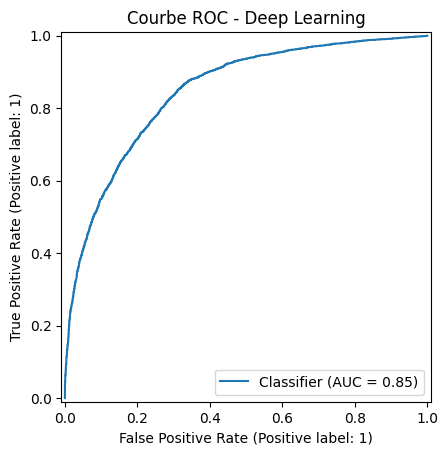

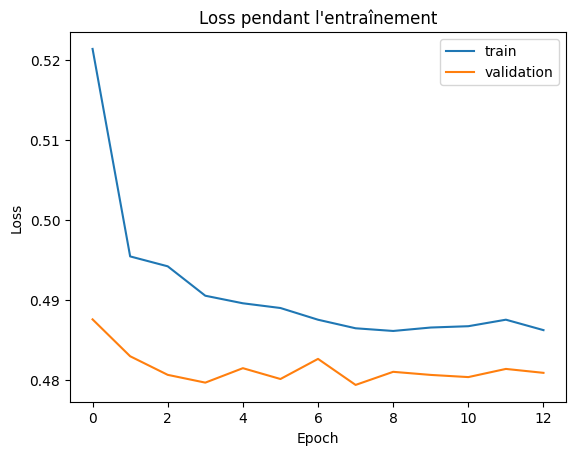


=== LOSS TRAIN / VALIDATION ===
Epoch 1 | Train Loss: 0.5214 | Validation Loss: 0.4876
Epoch 2 | Train Loss: 0.4954 | Validation Loss: 0.4829
Epoch 3 | Train Loss: 0.4942 | Validation Loss: 0.4806
Epoch 4 | Train Loss: 0.4905 | Validation Loss: 0.4796
Epoch 5 | Train Loss: 0.4896 | Validation Loss: 0.4814
Epoch 6 | Train Loss: 0.4890 | Validation Loss: 0.4801
Epoch 7 | Train Loss: 0.4875 | Validation Loss: 0.4826
Epoch 8 | Train Loss: 0.4864 | Validation Loss: 0.4793
Epoch 9 | Train Loss: 0.4861 | Validation Loss: 0.4810
Epoch 10 | Train Loss: 0.4865 | Validation Loss: 0.4806
Epoch 11 | Train Loss: 0.4867 | Validation Loss: 0.4803
Epoch 12 | Train Loss: 0.4875 | Validation Loss: 0.4814
Epoch 13 | Train Loss: 0.4862 | Validation Loss: 0.4809


In [5]:
# MLP ECHANTILLON 
# 1️⃣ IMPORTS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# =====================================================
# 2️⃣ PREPARATION DES DONNEES
# =====================================================

df_clean = pd.read_csv("df_clean.csv")
df_model = df_clean.copy()

df_model = df_model.sample(n=50000, random_state=42)

cols_datetime = ["arrivee_dt", "box_dt", "pec_dt", "sortie_dt"]

for col in cols_datetime:
    df_model[col] = pd.to_datetime(df_model[col], errors="coerce")


# =====================================================
# 3️⃣ CALCUL DUREE TRAITEMENT
# =====================================================

df_model["duree_traitement_h"] = (
    df_model["sortie_dt"] - df_model["pec_dt"]
).dt.total_seconds() / 3600


df_model = df_model.dropna(subset=["duree_traitement_h"])

df_model = df_model[
    (df_model["duree_traitement_h"] > 0) &
    (df_model["duree_traitement_h"] < 48)
]

print("Taille dataset :", len(df_model))


# =====================================================
# 4️⃣ VARIABLE CIBLE
# =====================================================

df_model["traitement_prolonge"] = (df_model["duree_traitement_h"] >= 3).astype(int)

print("Répartition classes :")
print(df_model["traitement_prolonge"].value_counts(normalize=True))


# =====================================================
# 5️⃣ FEATURES
# =====================================================

df_model["hospitalisation"] = (
    df_model["Orientation->type d'orientation"]
    .astype(str)
    .str.contains("HOSP", case=False)
    .astype(int)
)

features = [
    "Patient->age en année",
    "heure_arrivee",
    "mois",
    "Diagnostic->Code CCMU",
    "Examens complémentaires->a des examens de scanner",
    "Examens complémentaires->a des examens de biologie",
    "Examens complémentaires->a des examens de radiologie",
    "hospitalisation"
]

X = df_model[features]
y = df_model["traitement_prolonge"]

X = pd.get_dummies(X, drop_first=True)


# =====================================================
# 6️⃣ TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =====================================================
# 7️⃣ NORMALISATION
# =====================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =====================================================
# 8️⃣ MODELE DEEP LEARNING
# =====================================================

model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# =====================================================
# 9️⃣ ENTRAINEMENT
# =====================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


# =====================================================
# 🔟 PREDICTIONS
# =====================================================

y_proba = model.predict(X_test).flatten()

y_pred = (y_proba >= 0.5).astype(int)


print("\n=== RESULTATS SEUIL 0.5 ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("AUC ROC :", roc_auc_score(y_test, y_proba))

print(classification_report(y_test, y_pred))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))


# =====================================================
# 1️⃣1️⃣ AJUSTEMENT DU SEUIL
# =====================================================

threshold = 0.30

y_pred_adjusted = (y_proba >= threshold).astype(int)

print("\n=== RESULTATS SEUIL AJUSTE :", threshold, "===")

print(classification_report(y_test, y_pred_adjusted))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_adjusted))


# =====================================================
# 1️⃣2️⃣ COURBE ROC
# =====================================================

RocCurveDisplay.from_predictions(y_test, y_proba)

plt.title("Courbe ROC - Deep Learning")
plt.show()


# =====================================================
# 1️⃣3️⃣ COURBE D'APPRENTISSAGE
# =====================================================

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss pendant l'entraînement")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["train", "validation"])

plt.show()


print("\n=== LOSS TRAIN / VALIDATION ===")

for i in range(len(history.history["loss"])):
    print(
        f"Epoch {i+1} | "
        f"Train Loss: {history.history['loss'][i]:.4f} | "
        f"Validation Loss: {history.history['val_loss'][i]:.4f}"
    )

=== RESULTATS SEUIL 0.5 ===
Accuracy : 0.7647533425541724
AUC ROC : 0.8465959979214971
              precision    recall  f1-score   support 

           0       0.82      0.71      0.76      4610
           1       0.72      0.83      0.77      4066           

    accuracy                           0.76      8676
   macro avg       0.77      0.77      0.76      8676
weighted avg       0.77      0.76      0.76      8676

Matrice de confusion :
[[3273 1337]
 [ 704 3362]]

Classe	                   Precision	Recall	F1-score	Support
Traitement court (réel)   	0.86	   0.64	    0.73	     4610
Traitement prolongé (réel)	0.68	   0.88	    0.77	    4066

=== RESULTATS SEUIL AJUSTE : 0.3 ===
              precision    recall  f1-score   support

           0       0.86      0.64      0.73      4610
           1       0.68      0.88      0.77      4066

    accuracy                           0.75      8676
   macro avg       0.77      0.76      0.75      8676
weighted avg       0.78      0.75      0.75      8676

Matrice de confusion :
[[2932 1678]
 [ 471 3595]]

 	         Prédit court	Prédit prolongé
Court réel   	2932	        1678
Prolongé réel	471	            3595

Afin d'améliorer la détection des traitements longs, le seuil de classification a été ajusté de 0.5 à 0.3. Avec un seuil de 0.3, le rappel (recall) de la classe correspondant aux durées de traitement longues augmente de 0.83 à 0.88, ce qui signifie que le modèle identifie une plus grande proportion de patients dont la durée de traitement est réellement longue. Bien que cet ajustement entraîne une légère diminution de la précision et de l’accuracy globale, il permet de réduire le nombre de faux négatifs, c’est-à-dire les cas où une durée de traitement longue serait mal classée comme courte. Dans un contexte hospitalier, détecter au maximum les traitements longs est important afin d’anticiper l’utilisation des ressources et améliorer l’organisation du service. Ainsi, le seuil de 0.3 apparaît plus adapté à l’objectif du modèle.


/tmp/ipykernel_9515/3789635912.py:28: DtypeWarning: Columns (11,12,14,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("df_clean.csv")


Taille dataset : 290971
Répartition classes :
traitement_prolonge
0    0.531672
1    0.468328
Name: proportion, dtype: float64


/opt/jupyterlab-2024/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
5820/5820 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.7545 - loss: 0.5084 - val_accuracy: 0.7664 - val_loss: 0.4803
Epoch 2/50
5820/5820 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.7667 - loss: 0.4876 - val_accuracy: 0.7680 - val_loss: 0.4796
Epoch 3/50
5820/5820 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.7648 - loss: 0.4890 - val_accuracy: 0.7695 - val_loss: 0.4798
Epoch 4/50
5820/5820 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.7657 - loss: 0.4894 - val_accuracy: 0.7687 - val_loss: 0.4781
Epoch 5/50
5820/5820 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.7664 - loss: 0.4867 - val_accuracy: 0.7690 - val_loss: 0.4781
Epoch 6/50
5820/5820 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.7644 - loss: 0.4872 - val_accuracy: 0.7685 - val_loss: 0.4786
Epoch 7/50
5820/5820 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.7684 - loss: 0.4838 - val_accuracy: 0.7687 - val_loss: 0.4778
Epoch 8/50
5820/5820 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.7640 - loss: 0

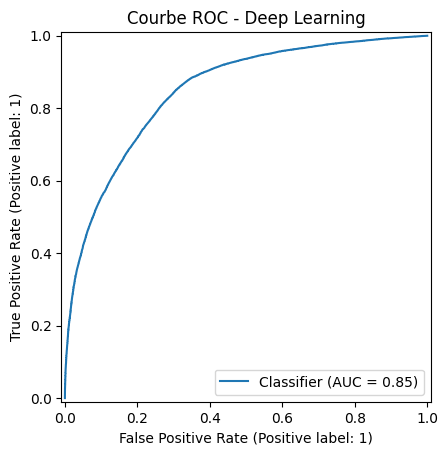

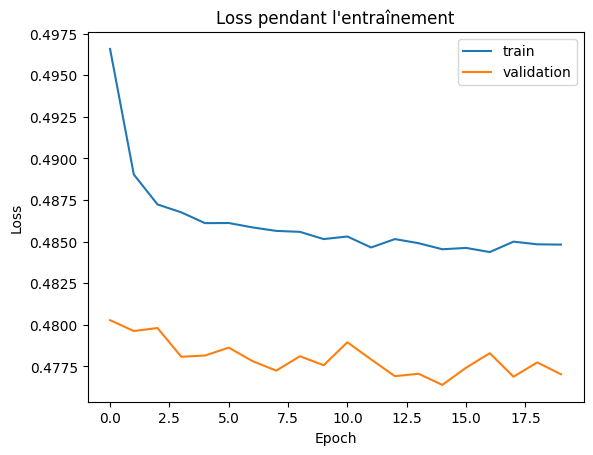


=== LOSS TRAIN / VALIDATION ===
Epoch 1 | Train Loss: 0.4966 | Validation Loss: 0.4803
Epoch 2 | Train Loss: 0.4890 | Validation Loss: 0.4796
Epoch 3 | Train Loss: 0.4872 | Validation Loss: 0.4798
Epoch 4 | Train Loss: 0.4868 | Validation Loss: 0.4781
Epoch 5 | Train Loss: 0.4861 | Validation Loss: 0.4781
Epoch 6 | Train Loss: 0.4861 | Validation Loss: 0.4786
Epoch 7 | Train Loss: 0.4859 | Validation Loss: 0.4778
Epoch 8 | Train Loss: 0.4856 | Validation Loss: 0.4772
Epoch 9 | Train Loss: 0.4856 | Validation Loss: 0.4781
Epoch 10 | Train Loss: 0.4851 | Validation Loss: 0.4776
Epoch 11 | Train Loss: 0.4853 | Validation Loss: 0.4789
Epoch 12 | Train Loss: 0.4846 | Validation Loss: 0.4779
Epoch 13 | Train Loss: 0.4851 | Validation Loss: 0.4769
Epoch 14 | Train Loss: 0.4849 | Validation Loss: 0.4771
Epoch 15 | Train Loss: 0.4845 | Validation Loss: 0.4764
Epoch 16 | Train Loss: 0.4846 | Validation Loss: 0.4774
Epoch 17 | Train Loss: 0.4844 | Validation Loss: 0.4783
Epoch 18 | Train Loss: 0

In [6]:
# MLP TOUTE LA BASE 
# 1️⃣ IMPORTS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# =====================================================
# 2️⃣ PREPARATION DES DONNEES
# =====================================================

df_clean = pd.read_csv("df_clean.csv")
df_model = df_clean.copy()

#df_model = df_model.sample(n=50000, random_state=42)

cols_datetime = ["arrivee_dt", "box_dt", "pec_dt", "sortie_dt"]

for col in cols_datetime:
    df_model[col] = pd.to_datetime(df_model[col], errors="coerce")


# =====================================================
# 3️⃣ CALCUL DUREE TRAITEMENT
# =====================================================

df_model["duree_traitement_h"] = (
    df_model["sortie_dt"] - df_model["pec_dt"]
).dt.total_seconds() / 3600


df_model = df_model.dropna(subset=["duree_traitement_h"])

df_model = df_model[
    (df_model["duree_traitement_h"] > 0) &
    (df_model["duree_traitement_h"] < 48)
]

print("Taille dataset :", len(df_model))


# =====================================================
# 4️⃣ VARIABLE CIBLE
# =====================================================

df_model["traitement_prolonge"] = (df_model["duree_traitement_h"] >= 3).astype(int)

print("Répartition classes :")
print(df_model["traitement_prolonge"].value_counts(normalize=True))


# =====================================================
# 5️⃣ FEATURES
# =====================================================

df_model["hospitalisation"] = (
    df_model["Orientation->type d'orientation"]
    .astype(str)
    .str.contains("HOSP", case=False)
    .astype(int)
)

features = [
    "Patient->age en année",
    "heure_arrivee",
    "mois",
    "Diagnostic->Code CCMU",
    "Examens complémentaires->a des examens de scanner",
    "Examens complémentaires->a des examens de biologie",
    "Examens complémentaires->a des examens de radiologie",
    "hospitalisation"
]

X = df_model[features]
y = df_model["traitement_prolonge"]

X = pd.get_dummies(X, drop_first=True)


# =====================================================
# 6️⃣ TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =====================================================
# 7️⃣ NORMALISATION
# =====================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =====================================================
# 8️⃣ MODELE DEEP LEARNING
# =====================================================

model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# =====================================================
# 9️⃣ ENTRAINEMENT
# =====================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


# =====================================================
# 🔟 PREDICTIONS
# =====================================================

y_proba = model.predict(X_test).flatten()

y_pred = (y_proba >= 0.5).astype(int)


print("\n=== RESULTATS SEUIL 0.5 ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("AUC ROC :", roc_auc_score(y_test, y_proba))

print(classification_report(y_test, y_pred))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))


# =====================================================
# 1️⃣1️⃣ AJUSTEMENT DU SEUIL
# =====================================================

threshold = 0.30

y_pred_adjusted = (y_proba >= threshold).astype(int)

print("\n=== RESULTATS SEUIL AJUSTE :", threshold, "===")

print(classification_report(y_test, y_pred_adjusted))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_adjusted))


# =====================================================
# 1️⃣2️⃣ COURBE ROC
# =====================================================

RocCurveDisplay.from_predictions(y_test, y_proba)

plt.title("Courbe ROC - Deep Learning")
plt.show()


# =====================================================
# 1️⃣3️⃣ COURBE D'APPRENTISSAGE
# =====================================================

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss pendant l'entraînement")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["train", "validation"])

plt.show()


print("\n=== LOSS TRAIN / VALIDATION ===")

for i in range(len(history.history["loss"])):
    print(
        f"Epoch {i+1} | "
        f"Train Loss: {history.history['loss'][i]:.4f} | "
        f"Validation Loss: {history.history['val_loss'][i]:.4f}"
    )

In [ ]:
###SciKeras est une bibliothèque Python qui permet d’utiliser les modèles Keras avec les outils de scikit-learn.

/tmp/ipykernel_9515/2968045269.py:28: DtypeWarning: Columns (11,12,14,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("df_clean.csv")


Taille dataset : 281185
Répartition classes :
traitement_prolonge
0    0.550175
1    0.449825
Name: proportion, dtype: float64
Entraînement en cours...
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

=== RESULTATS SEUIL 0.5 ===
Accuracy : 0.7627718406031616
AUC ROC : 0.8428266876003064
              precision    recall  f1-score   support

           0       0.81      0.74      0.78     30940
           1       0.72      0.79      0.75     25297

    accuracy                           0.76     56237
   macro avg       0.76      0.76      0.76     56237
weighted avg       0.77      0.76      0.76     56237

Matrice de confusion :
[[23022  7918]
 [ 5423 19874]]

=== RESULTATS SEUIL AJUSTE : 0.3 ===
              precision    recall  f1-score   support

           0       0.87      0.65      0.74     30940
           1       0.67      0.88      0.76     25297

    accuracy                           0.75     56237
   macro avg       0.77      0.76      0

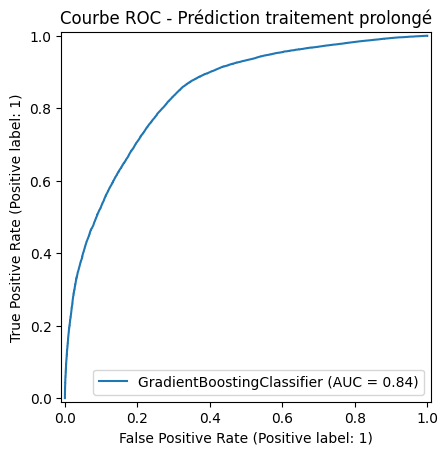


Importance des variables :
Examens complémentaires->a des examens de biologie_oui      0.679646
Examens complémentaires->a des examens de scanner_oui       0.162730
Patient->age en année                                       0.056042
Examens complémentaires->a des examens de radiologie_oui    0.034473
heure_arrivee                                               0.022378
Diagnostic->Code CCMU_3                                     0.021731
Diagnostic->Code CCMU_2                                     0.008157
Diagnostic->Code CCMU_P                                     0.007035
Diagnostic->Code CCMU_5                                     0.002954
Diagnostic->Code CCMU_4                                     0.002359
mois                                                        0.001906
Diagnostic->Code CCMU_D                                     0.000588
hospitalisation                                             0.000000
dtype: float64


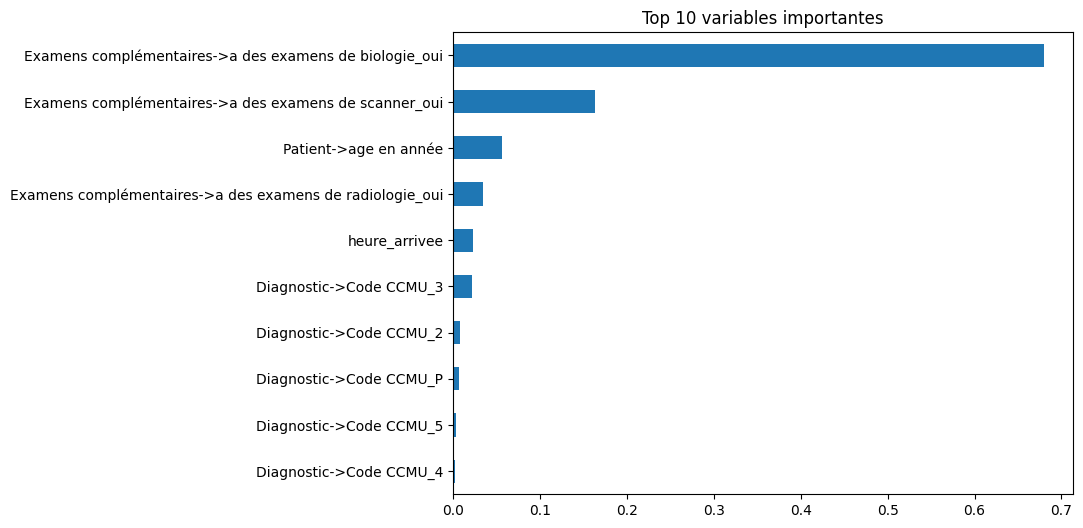


Evolution de la LOSS :
Iteration 0 | Train Loss = 0.6558 | Test Loss = 0.656
Iteration 20 | Train Loss = 0.496 | Test Loss = 0.4985
Iteration 40 | Train Loss = 0.4858 | Test Loss = 0.4889
Iteration 60 | Train Loss = 0.4833 | Test Loss = 0.4869
Iteration 80 | Train Loss = 0.4823 | Test Loss = 0.4862
Iteration 100 | Train Loss = 0.4817 | Test Loss = 0.4859
Iteration 120 | Train Loss = 0.4813 | Test Loss = 0.4857
Iteration 140 | Train Loss = 0.4809 | Test Loss = 0.4856
Iteration 160 | Train Loss = 0.4806 | Test Loss = 0.4856
Iteration 180 | Train Loss = 0.4803 | Test Loss = 0.4856


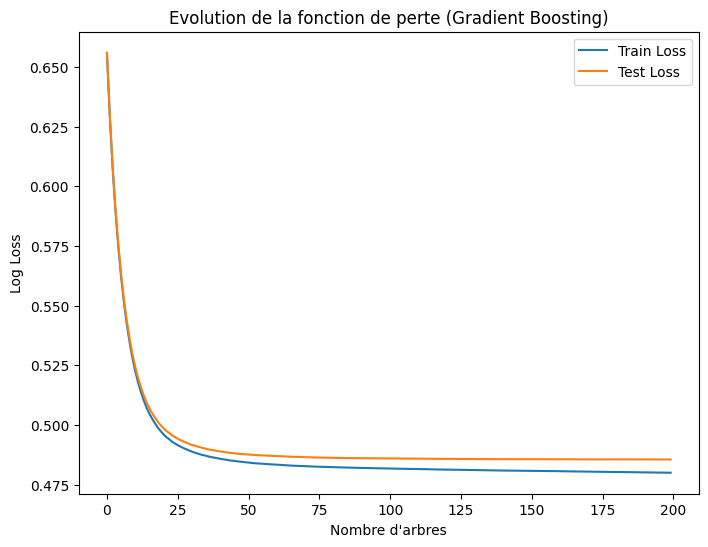

In [18]:
# GradientBoostingClassifier AVEC SEUIL 0.3 & 0.5  SUR TOUTE LA BASE

# PREDICTION TRAITEMENT PROLONGE

# =====================================================
# 1️⃣ IMPORTS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    log_loss
)

# =====================================================
# 2️⃣ PREPARATION DES DONNEES
# =====================================================

df_clean = pd.read_csv("df_clean.csv")
df_model = df_clean.copy()

# Conversion datetime
cols_datetime = ["arrivee_dt", "box_dt", "pec_dt", "sortie_dt"]

for col in cols_datetime:
    df_model[col] = pd.to_datetime(df_model[col], errors="coerce")

# =====================================================
# 3️⃣ DUREE DE TRAITEMENT
# =====================================================

df_model["duree_traitement_h"] = (
    df_model["sortie_dt"] - df_model["pec_dt"]
).dt.total_seconds() / 3600

df_model = df_model.dropna(subset=["duree_traitement_h"])

# filtre valeurs réalistes
df_model = df_model[
    (df_model["duree_traitement_h"] > 0) &
    (df_model["duree_traitement_h"] < 24)
]

print("Taille dataset :", len(df_model))

# =====================================================
# 4️⃣ VARIABLE CIBLE
# =====================================================

df_model["traitement_prolonge"] = (df_model["duree_traitement_h"] >= 3).astype(int)

print("Répartition classes :")
print(df_model["traitement_prolonge"].value_counts(normalize=True))

# =====================================================
# 5️⃣ FEATURES
# =====================================================

df_model["hospitalisation"] = (
    df_model["Orientation->type d'orientation"]
    .astype(str)
    .str.contains("HOSP", case=False)
    .astype(int)
)

features = [
    "Patient->age en année",
    "heure_arrivee",
    "mois",
    "Diagnostic->Code CCMU",
    "Examens complémentaires->a des examens de scanner",
    "Examens complémentaires->a des examens de biologie",
    "Examens complémentaires->a des examens de radiologie",
    "hospitalisation"
]

X = df_model[features]
y = df_model["traitement_prolonge"]

# Encodage catégoriel
X = pd.get_dummies(X, drop_first=True)

# =====================================================
# 6️⃣ TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 7️⃣ GRIDSEARCH
# =====================================================

clf = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators": [200],
    "learning_rate": [0.1],
    "max_depth": [4]
}

grid = GridSearchCV(
    clf,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

print("Entraînement en cours...")
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Meilleurs paramètres :", grid.best_params_)

# =====================================================
# 8️⃣ EVALUATION STANDARD
# =====================================================

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== RESULTATS SEUIL 0.5 ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("AUC ROC :", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

# =====================================================
# 9️⃣ SEUIL AJUSTE
# =====================================================

threshold = 0.30

y_pred_adjusted = (y_proba >= threshold).astype(int)

print("\n=== RESULTATS SEUIL AJUSTE :", threshold, "===")
print(classification_report(y_test, y_pred_adjusted))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_adjusted))

# =====================================================
# 🔟 COURBE ROC
# =====================================================

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title("Courbe ROC - Prédiction traitement prolongé")
plt.show()

# =====================================================
# 1️⃣1️⃣ IMPORTANCE DES VARIABLES
# =====================================================

importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nImportance des variables :")
print(importances)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")

plt.gca().invert_yaxis()
plt.title("Top 10 variables importantes")
plt.show()

# =====================================================
# 1️⃣2️⃣ EVOLUTION DE LA LOSS
# =====================================================

train_loss = []
test_loss = []

for y_pred_train, y_pred_test in zip(
    best_model.staged_predict_proba(X_train),
    best_model.staged_predict_proba(X_test)
):

    train_loss.append(log_loss(y_train, y_pred_train))
    test_loss.append(log_loss(y_test, y_pred_test))

# Affichage des valeurs
print("\nEvolution de la LOSS :")

for i in range(0, len(train_loss), 20):
    print(
        "Iteration", i,
        "| Train Loss =", round(train_loss[i],4),
        "| Test Loss =", round(test_loss[i],4)
    )

# Graphique
plt.figure(figsize=(8,6))

plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")

plt.xlabel("Nombre d'arbres")
plt.ylabel("Log Loss")
plt.title("Evolution de la fonction de perte (Gradient Boosting)")

plt.legend()
plt.show()




=== LEARNING CURVE ===
Taille entraînement : 22494 | Train AUC = 0.874 | Test AUC = 0.835
Taille entraînement : 44989 | Train AUC = 0.868 | Test AUC = 0.836
Taille entraînement : 67484 | Train AUC = 0.864 | Test AUC = 0.836
Taille entraînement : 89979 | Train AUC = 0.86 | Test AUC = 0.837
Taille entraînement : 112474 | Train AUC = 0.858 | Test AUC = 0.838
Taille entraînement : 134968 | Train AUC = 0.854 | Test AUC = 0.84
Taille entraînement : 157463 | Train AUC = 0.851 | Test AUC = 0.841
Taille entraînement : 179958 | Train AUC = 0.85 | Test AUC = 0.841
Taille entraînement : 202453 | Train AUC = 0.848 | Test AUC = 0.842
Taille entraînement : 224948 | Train AUC = 0.846 | Test AUC = 0.842


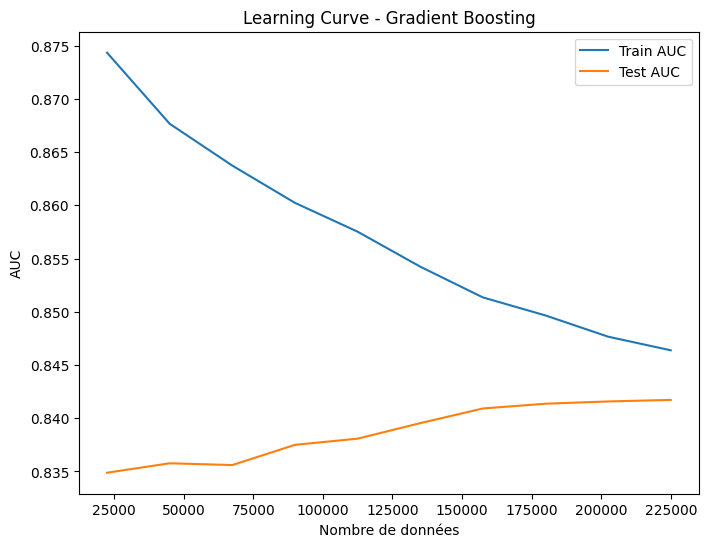

In [19]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

print("\n=== LEARNING CURVE ===")

for size, train, test in zip(train_sizes, train_mean, test_mean):

    print(
        "Taille entraînement :", size,
        "| Train AUC =", round(train,3),
        "| Test AUC =", round(test,3)
    )

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Train AUC")
plt.plot(train_sizes, test_mean, label="Test AUC")

plt.xlabel("Nombre de données")
plt.ylabel("AUC")
plt.title("Learning Curve - Gradient Boosting")

plt.legend()
plt.show()


=== CALIBRATION ===
Probabilité prédite = 0.08 | Fréquence réelle = 0.073
Probabilité prédite = 0.141 | Fréquence réelle = 0.142
Probabilité prédite = 0.24 | Fréquence réelle = 0.269
Probabilité prédite = 0.342 | Fréquence réelle = 0.343
Probabilité prédite = 0.458 | Fréquence réelle = 0.454
Probabilité prédite = 0.554 | Fréquence réelle = 0.553
Probabilité prédite = 0.642 | Fréquence réelle = 0.646
Probabilité prédite = 0.752 | Fréquence réelle = 0.737
Probabilité prédite = 0.856 | Fréquence réelle = 0.852
Probabilité prédite = 0.937 | Fréquence réelle = 0.936


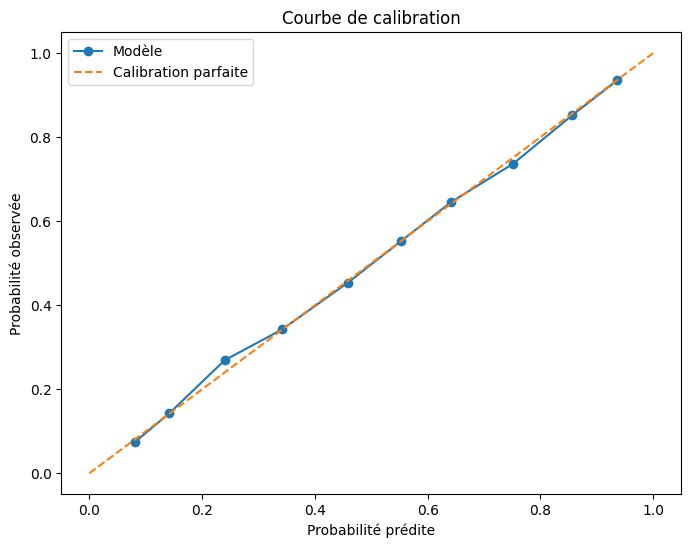

In [20]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba,
    n_bins=10
)

print("\n=== CALIBRATION ===")

for p_pred, p_true in zip(prob_pred, prob_true):

    print(
        "Probabilité prédite =", round(p_pred,3),
        "| Fréquence réelle =", round(p_true,3)
    )

plt.figure(figsize=(8,6))

plt.plot(prob_pred, prob_true, marker="o", label="Modèle")
plt.plot([0,1],[0,1], linestyle="--", label="Calibration parfaite")

plt.xlabel("Probabilité prédite")
plt.ylabel("Probabilité observée")

plt.title("Courbe de calibration")

plt.legend()
plt.show()

/tmp/ipykernel_9515/3770828121.py:28: DtypeWarning: Columns (11,12,14,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("df_clean.csv")


Taille dataset : 125869
Répartition classes :
traitement_prolonge
0    0.549524
1    0.450476
Name: proportion, dtype: float64
Entraînement en cours...
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}

=== RESULTATS SEUIL 0.5 ===
Accuracy : 0.7609438309366807
AUC ROC : 0.8406377017847549
              precision    recall  f1-score   support

           0       0.80      0.75      0.77     13834
           1       0.72      0.78      0.75     11340

    accuracy                           0.76     25174
   macro avg       0.76      0.76      0.76     25174
weighted avg       0.76      0.76      0.76     25174

Matrice de confusion :
[[10322  3512]
 [ 2506  8834]]

=== RESULTATS SEUIL AJUSTE : 0.3 ===
              precision    recall  f1-score   support

           0       0.87      0.65      0.74     13834
           1       0.67      0.88      0.76     11340

    accuracy                           0.75     25174
   macro avg       0.77      0.76      0

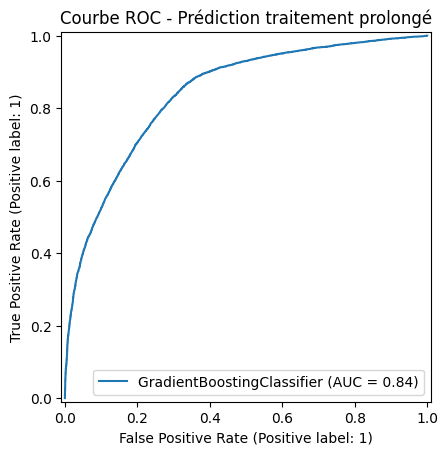


Importance des variables :
Examens complémentaires->a des examens de biologie_oui      0.675700
Examens complémentaires->a des examens de scanner_oui       0.158507
Patient->age en année                                       0.059609
Examens complémentaires->a des examens de radiologie_oui    0.034849
heure_arrivee                                               0.026773
Diagnostic->Code CCMU_3                                     0.021151
Diagnostic->Code CCMU_2                                     0.007958
Diagnostic->Code CCMU_P                                     0.007164
mois                                                        0.003362
Diagnostic->Code CCMU_4                                     0.002524
Diagnostic->Code CCMU_5                                     0.002156
Diagnostic->Code CCMU_D                                     0.000246
hospitalisation                                             0.000000
dtype: float64


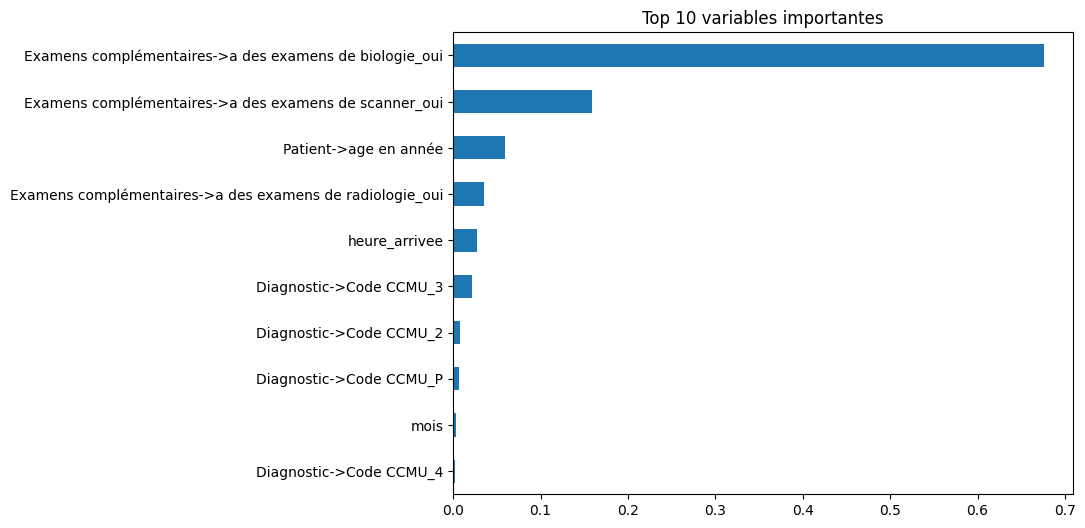


Evolution de la LOSS :
Iteration 0 | Train Loss = 0.6559 | Test Loss = 0.6561
Iteration 20 | Train Loss = 0.4954 | Test Loss = 0.4987
Iteration 40 | Train Loss = 0.4848 | Test Loss = 0.4895
Iteration 60 | Train Loss = 0.4821 | Test Loss = 0.4879
Iteration 80 | Train Loss = 0.4808 | Test Loss = 0.4875
Iteration 100 | Train Loss = 0.48 | Test Loss = 0.4874
Iteration 120 | Train Loss = 0.4794 | Test Loss = 0.4874
Iteration 140 | Train Loss = 0.4788 | Test Loss = 0.4873
Iteration 160 | Train Loss = 0.4782 | Test Loss = 0.4874
Iteration 180 | Train Loss = 0.4776 | Test Loss = 0.4874


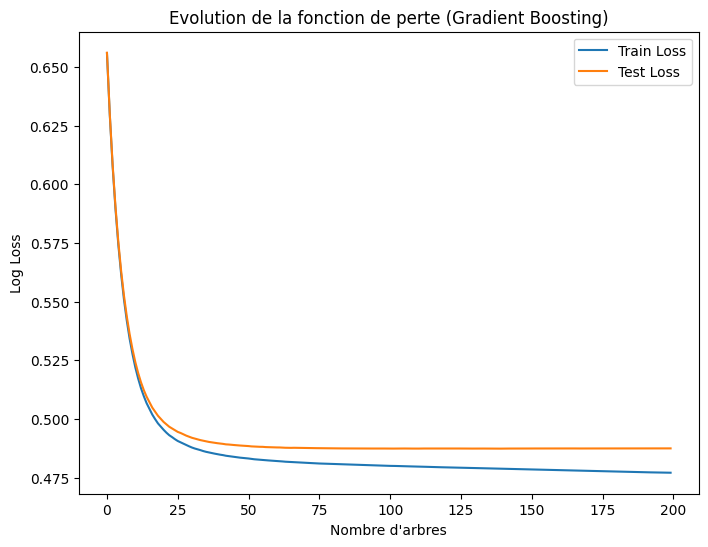

In [16]:
# GradientBoostingClassifier AVEC SEUIL 0.3 & 0.5  SUR UN ECHANTILLON

# PREDICTION TRAITEMENT PROLONGE

# =====================================================
# 1️⃣ IMPORTS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    log_loss
)

# =====================================================
# 2️⃣ PREPARATION DES DONNEES
# =====================================================

df_clean = pd.read_csv("df_clean.csv")
df_model = df_clean.copy()
df_model = df_model.sample(n=150000, random_state=42)


# Conversion datetime
cols_datetime = ["arrivee_dt", "box_dt", "pec_dt", "sortie_dt"]

for col in cols_datetime:
    df_model[col] = pd.to_datetime(df_model[col], errors="coerce")

# =====================================================
# 3️⃣ DUREE DE TRAITEMENT
# =====================================================

df_model["duree_traitement_h"] = (
    df_model["sortie_dt"] - df_model["pec_dt"]
).dt.total_seconds() / 3600

df_model = df_model.dropna(subset=["duree_traitement_h"])

# filtre valeurs réalistes
df_model = df_model[
    (df_model["duree_traitement_h"] > 0) &
    (df_model["duree_traitement_h"] < 24)
]

print("Taille dataset :", len(df_model))

# =====================================================
# 4️⃣ VARIABLE CIBLE
# =====================================================

df_model["traitement_prolonge"] = (df_model["duree_traitement_h"] >= 3).astype(int)

print("Répartition classes :")
print(df_model["traitement_prolonge"].value_counts(normalize=True))

# =====================================================
# 5️⃣ FEATURES
# =====================================================

df_model["hospitalisation"] = (
    df_model["Orientation->type d'orientation"]
    .astype(str)
    .str.contains("HOSP", case=False)
    .astype(int)
)

features = [
    "Patient->age en année",
    "heure_arrivee",
    "mois",
    "Diagnostic->Code CCMU",
    "Examens complémentaires->a des examens de scanner",
    "Examens complémentaires->a des examens de biologie",
    "Examens complémentaires->a des examens de radiologie",
    "hospitalisation"
]

X = df_model[features]
y = df_model["traitement_prolonge"]

# Encodage catégoriel
X = pd.get_dummies(X, drop_first=True)

# =====================================================
# 6️⃣ TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =====================================================
# 7️⃣ GRIDSEARCH
# =====================================================

clf = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators": [200],
    "learning_rate": [0.1],
    "max_depth": [4]
}

grid = GridSearchCV(
    clf,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

print("Entraînement en cours...")
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Meilleurs paramètres :", grid.best_params_)

# =====================================================
# 8️⃣ EVALUATION STANDARD
# =====================================================

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== RESULTATS SEUIL 0.5 ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("AUC ROC :", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

# =====================================================
# 9️⃣ SEUIL AJUSTE
# =====================================================

threshold = 0.30

y_pred_adjusted = (y_proba >= threshold).astype(int)

print("\n=== RESULTATS SEUIL AJUSTE :", threshold, "===")
print(classification_report(y_test, y_pred_adjusted))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_adjusted))

# =====================================================
# 🔟 COURBE ROC
# =====================================================

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title("Courbe ROC - Prédiction traitement prolongé")
plt.show()

# =====================================================
# 1️⃣1️⃣ IMPORTANCE DES VARIABLES
# =====================================================

importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nImportance des variables :")
print(importances)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")

plt.gca().invert_yaxis()
plt.title("Top 10 variables importantes")
plt.show()

# =====================================================
# 1️⃣2️⃣ EVOLUTION DE LA LOSS
# =====================================================

train_loss = []
test_loss = []

for y_pred_train, y_pred_test in zip(
    best_model.staged_predict_proba(X_train),
    best_model.staged_predict_proba(X_test)
):

    train_loss.append(log_loss(y_train, y_pred_train))
    test_loss.append(log_loss(y_test, y_pred_test))

# Affichage des valeurs
print("\nEvolution de la LOSS :")

for i in range(0, len(train_loss), 20):
    print(
        "Iteration", i,
        "| Train Loss =", round(train_loss[i],4),
        "| Test Loss =", round(test_loss[i],4)
    )

# Graphique
plt.figure(figsize=(8,6))

plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")

plt.xlabel("Nombre d'arbres")
plt.ylabel("Log Loss")
plt.title("Evolution de la fonction de perte (Gradient Boosting)")

plt.legend()
plt.show()



=== LEARNING CURVE ===
Taille entraînement : 10069 | Train AUC = 0.876 | Test AUC = 0.834
Taille entraînement : 20139 | Train AUC = 0.863 | Test AUC = 0.838
Taille entraînement : 30208 | Train AUC = 0.857 | Test AUC = 0.84
Taille entraînement : 40278 | Train AUC = 0.853 | Test AUC = 0.841
Taille entraînement : 50347 | Train AUC = 0.852 | Test AUC = 0.842
Taille entraînement : 60417 | Train AUC = 0.851 | Test AUC = 0.842
Taille entraînement : 70486 | Train AUC = 0.85 | Test AUC = 0.842
Taille entraînement : 80556 | Train AUC = 0.849 | Test AUC = 0.843
Taille entraînement : 90625 | Train AUC = 0.848 | Test AUC = 0.843
Taille entraînement : 100695 | Train AUC = 0.848 | Test AUC = 0.843


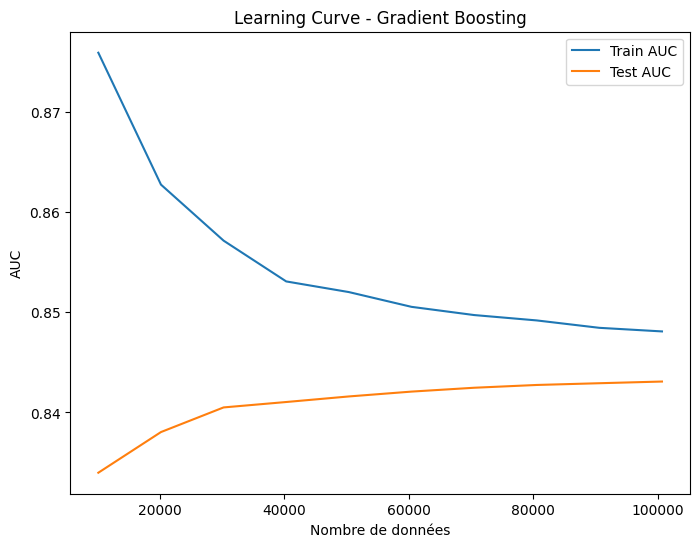

In [17]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

print("\n=== LEARNING CURVE ===")

for size, train, test in zip(train_sizes, train_mean, test_mean):

    print(
        "Taille entraînement :", size,
        "| Train AUC =", round(train,3),
        "| Test AUC =", round(test,3)
    )

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Train AUC")
plt.plot(train_sizes, test_mean, label="Test AUC")

plt.xlabel("Nombre de données")
plt.ylabel("AUC")
plt.title("Learning Curve - Gradient Boosting")

plt.legend()
plt.show()